# Import neccessary libraries

In [2]:
import numpy as np
import pandas as pd
from prophet import Prophet 

## Loading the data

In [3]:
df = pd.read_excel('SKUForecastDataSet.xlsx')

## Statistical summary

In [4]:
df.head()

,ProductFamily,order_id,OrderDate,Channel,OrderSource,SKU,SKU_Description,ShipToState,WareHouseQuanity,SKU_category
0,AirDoctor,38191,2023-01-01,organic_social,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units
1,AirDoctor,38197,2023-01-01,email,WEB,90AD550AD01,Air Doctor AD5500,CO,1.0,Main Units
2,AirDoctor,38226,2023-01-01,paid_social,WEB,90AD350AD01,Air Doctor AD3500,IL,2.0,Main Units
3,AirDoctor,38235,2023-01-01,email,WEB,30AD01B003,AD5500+AD3500 Bundle,MD,1.0,Bundles
4,AirDoctor,38235,2023-01-01,email,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units


In [5]:
df.shape

(858258, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858258 entries, 0 to 858257
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ProductFamily     858258 non-null  object        
 1   order_id          858258 non-null  int64         
 2   OrderDate         858258 non-null  datetime64[ns]
 3   Channel           858258 non-null  object        
 4   OrderSource       858258 non-null  object        
 5   SKU               842028 non-null  object        
 6   SKU_Description   858258 non-null  object        
 7   ShipToState       857852 non-null  object        
 8   WareHouseQuanity  777308 non-null  float64       
 9   SKU_category      755942 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 65.5+ MB


In [7]:
# Summary statistics
df.describe()

,order_id,OrderDate,WareHouseQuanity
count,8.582580e+05,858258,777308.000000
mean,7.237106e+05,2024-07-01 10:42:15.399845120,1.215491
min,3.683000e+04,2022-12-24 00:00:00,1.000000
25%,1.935790e+05,2023-11-24 00:00:00,1.000000
50%,4.053860e+05,2024-08-11 00:00:00,1.000000
75%,5.652810e+05,2025-01-30 00:00:00,1.000000
max,1.001882e+07,2025-07-17 00:00:00,40.000000
std,1.832057e+06,NaN,0.566094


### Before Dropping

In [8]:
df.shape

(858258, 10)

### Checking null/missing values

In [13]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 ProductFamily       0
order_id            0
OrderDate           0
Channel             0
OrderSource         0
SKU                 0
SKU_Description     0
ShipToState         0
WareHouseQuanity    0
SKU_category        0
Week                0
Month               0
Year                0
dtype: int64


### Dropping null values

In [14]:
# Drop rows with NULLs
df.dropna(inplace=True)

### After dropping null values

In [15]:
df.shape

(755567, 13)

### Feature Engineering

In [16]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year


In [17]:
df.head(-1)

,ProductFamily,order_id,OrderDate,Channel,OrderSource,SKU,SKU_Description,ShipToState,WareHouseQuanity,SKU_category,Week,Month,Year
0,AirDoctor,38191,2023-01-01,organic_social,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units,2022-12-26,1,2023
1,AirDoctor,38197,2023-01-01,email,WEB,90AD550AD01,Air Doctor AD5500,CO,1.0,Main Units,2022-12-26,1,2023
2,AirDoctor,38226,2023-01-01,paid_social,WEB,90AD350AD01,Air Doctor AD3500,IL,2.0,Main Units,2022-12-26,1,2023
3,AirDoctor,38235,2023-01-01,email,WEB,30AD01B003,AD5500+AD3500 Bundle,MD,1.0,Bundles,2022-12-26,1,2023
4,AirDoctor,38235,2023-01-01,email,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units,2022-12-26,1,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
858252,AirDoctor,503962,2024-12-31,email,WEB,90AD350AD01,Air Doctor AD3500,KY,2.0,Main Units,2024-12-30,12,2024
858253,AirDoctor,503885,2024-12-31,Main,WEB,40AD01WC301,3-Year Extended Warranty: AirDoctor 3500/3500 ...,AZ,1.0,Accessories,2024-12-30,12,2024
858254,AirDoctor,503698,2024-12-31,email,WEB,10AD500GRF02,AD5000 VOC/Gas/Carbon Filter (2pk),TX,2.0,Accessories,2024-12-30,12,2024
858255,AirDoctor,503750,2024-12-31,email,WEB,30AD350CMPK2,AD3500 2-Year Filter Pack,TX,1.0,Accessories,2024-12-30,12,2024


### Unique value check

In [18]:
df.nunique()

ProductFamily            1
order_id            457536
OrderDate              935
Channel                 22
OrderSource              6
SKU                    123
SKU_Description        120
ShipToState             95
WareHouseQuanity        24
SKU_category             5
Week                   135
Month                   12
Year                     4
dtype: int64

### Weekly Sales Trend

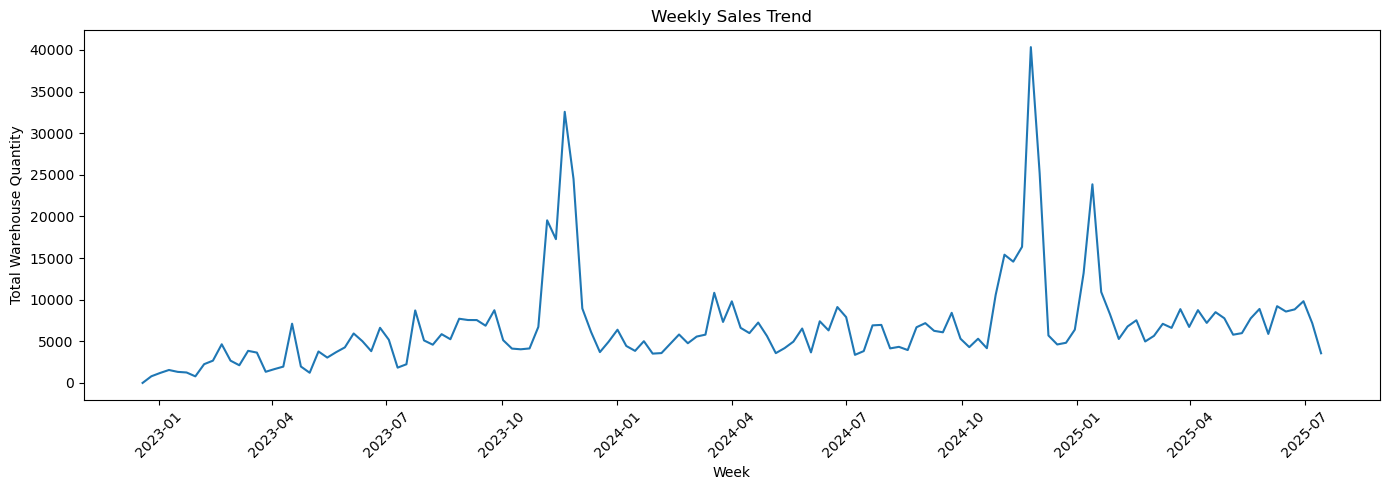

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

weekly_trend = df.groupby('Week')['WareHouseQuanity'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuanity')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Warehouse Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


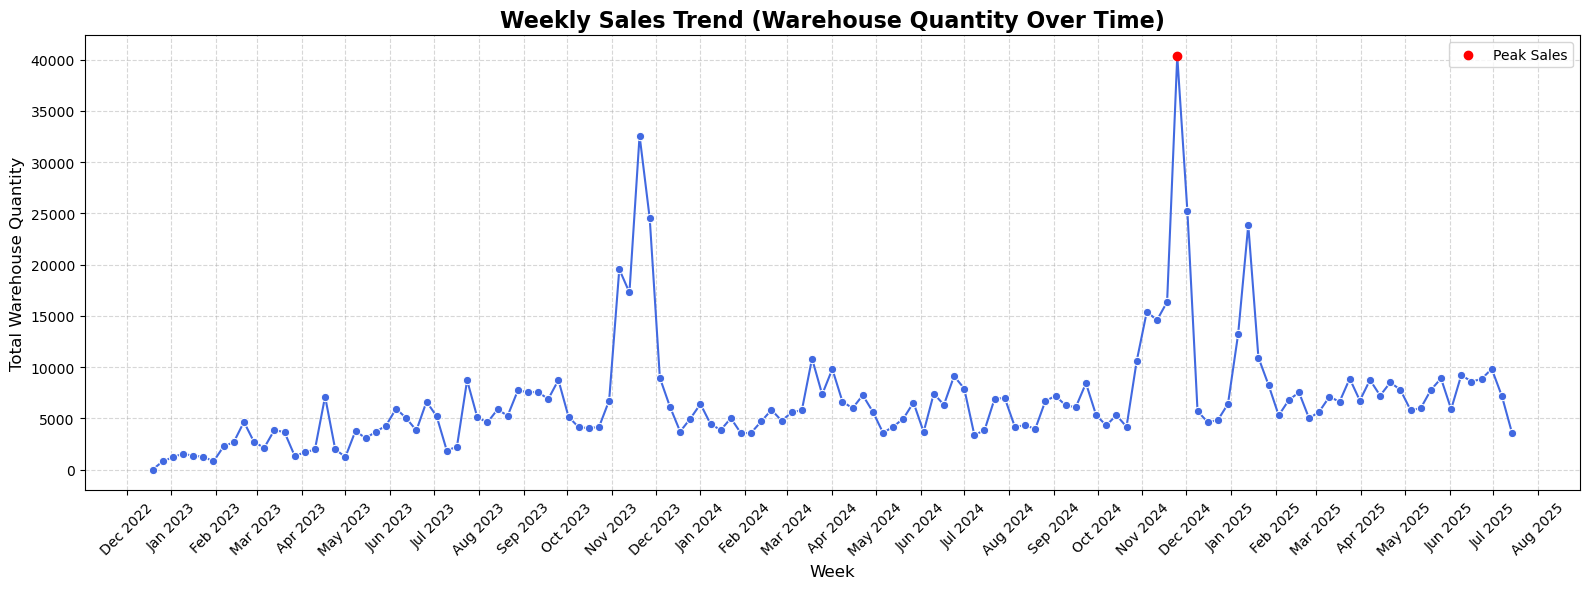

In [20]:
import matplotlib.dates as mdates

# Convert 'Week' to datetime if not already
weekly_trend['Week'] = pd.to_datetime(weekly_trend['Week'])

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuanity', marker='o', color='royalblue')

# Title and labels
plt.title("Weekly Sales Trend (Warehouse Quantity Over Time)", fontsize=16, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("Total Warehouse Quantity", fontsize=12)

# Format X-axis to show only one label per month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Optional: show every 2nd month to reduce clutter
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight peak
peak = weekly_trend[weekly_trend['WareHouseQuanity'] == weekly_trend['WareHouseQuanity'].max()]
plt.scatter(peak['Week'], peak['WareHouseQuanity'], color='red', label='Peak Sales', zorder=5)
plt.legend()

plt.tight_layout()
plt.show()


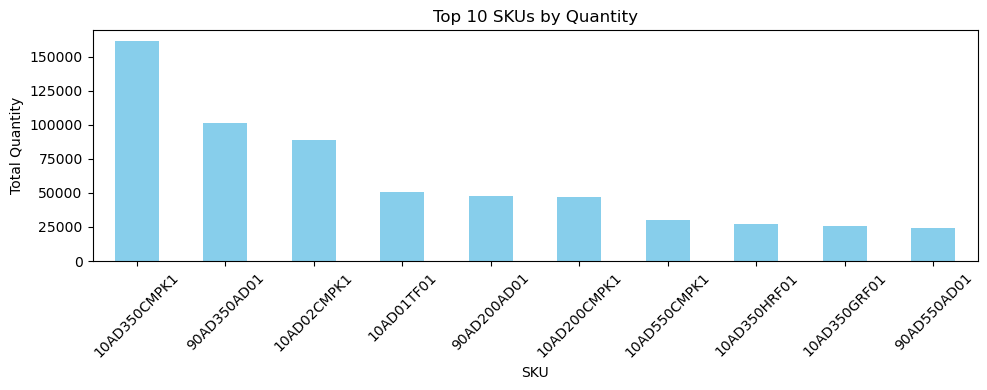

In [21]:
top_skus = df.groupby('SKU')['WareHouseQuanity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_skus.plot(kind='bar', color='skyblue')
plt.title("Top 10 SKUs by Quantity")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [35]:
top_skus

SKU
10AD350CMPK1    161434.0
90AD350AD01     101434.0
10AD02CMPK1      88696.0
10AD01TF01       50968.0
90AD200AD01      48025.0
10AD200CMPK1     46777.0
10AD550CMPK1     30141.0
10AD350HRF01     27302.0
10AD350GRF01     25835.0
90AD550AD01      24566.0
Name: WareHouseQuanity, dtype: float64

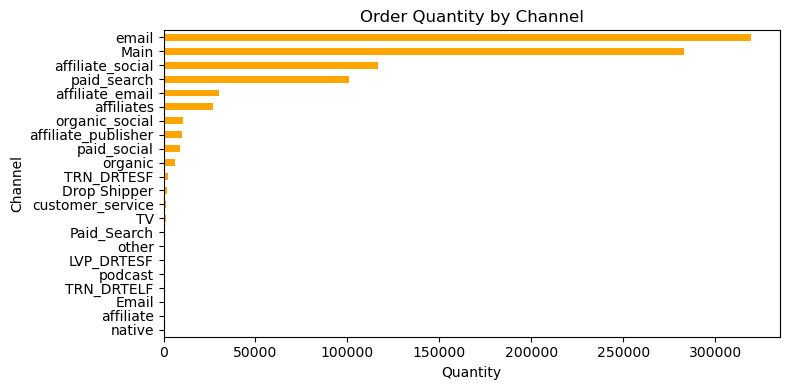

In [22]:
channel_orders = df.groupby('Channel')['WareHouseQuanity'].sum().sort_values()

plt.figure(figsize=(8, 4))
channel_orders.plot(kind='barh', color='orange')
plt.title("Order Quantity by Channel")
plt.xlabel("Quantity")
plt.tight_layout()
plt.show()


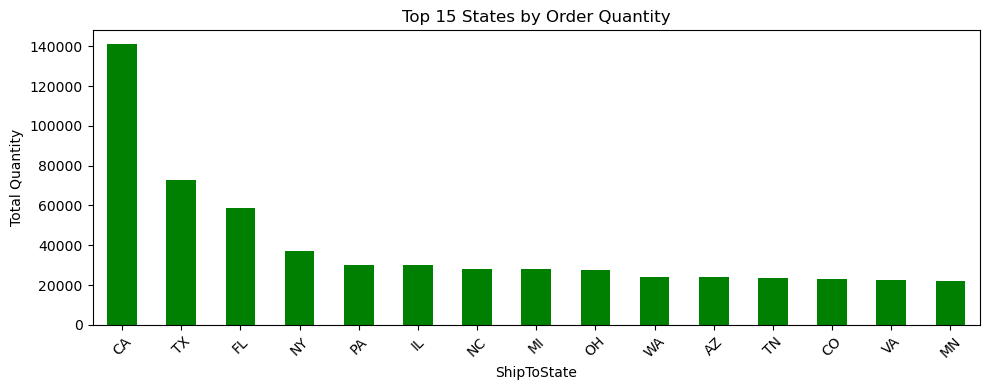

In [23]:
state_qty = df.groupby('ShipToState')['WareHouseQuanity'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 4))
state_qty.plot(kind='bar', color='green')
plt.title("Top 15 States by Order Quantity")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Label Encoding

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 755567 entries, 0 to 858257
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ProductFamily     755567 non-null  object        
 1   order_id          755567 non-null  int64         
 2   OrderDate         755567 non-null  datetime64[ns]
 3   Channel           755567 non-null  object        
 4   OrderSource       755567 non-null  object        
 5   SKU               755567 non-null  object        
 6   SKU_Description   755567 non-null  object        
 7   ShipToState       755567 non-null  object        
 8   WareHouseQuanity  755567 non-null  float64       
 9   SKU_category      755567 non-null  object        
 10  Week              755567 non-null  datetime64[ns]
 11  Month             755567 non-null  int32         
 12  Year              755567 non-null  int32         
dtypes: datetime64[ns](2), float64(1), int32(2), int64(1), object(7)


In [25]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe to avoid modifying the original
df_encoded = df.copy()

# List of categorical columns to encode
categorical_cols = [
    'ProductFamily', 'Channel', 'OrderSource', 
    'SKU', 'SKU_Description', 'ShipToState', 'SKU_category'
]

# Apply LabelEncoder to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Check the result
print(df_encoded.head())


   ProductFamily  order_id  OrderDate  Channel  OrderSource  SKU  \
0              0     38191 2023-01-01       17            5  116   
1              0     38197 2023-01-01       14            5  121   
2              0     38226 2023-01-01       20            5  116   
3              0     38235 2023-01-01       14            5   40   
4              0     38235 2023-01-01       14            5  116   

   SKU_Description  ShipToState  WareHouseQuanity  SKU_category       Week  \
0               98           35               1.0             3 2022-12-26   
1              103           11               1.0             3 2022-12-26   
2               98           28               2.0             3 2022-12-26   
3               79           35               1.0             1 2022-12-26   
4               98           35               1.0             3 2022-12-26   

   Month  Year  
0      1  2023  
1      1  2023  
2      1  2023  
3      1  2023  
4      1  2023  


### Feature Importance

Top selected features:
Index(['Channel', 'OrderSource', 'SKU', 'SKU_Description', 'ShipToState',
       'SKU_category', 'Month', 'Year'],
      dtype='object')


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_708\94853889.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


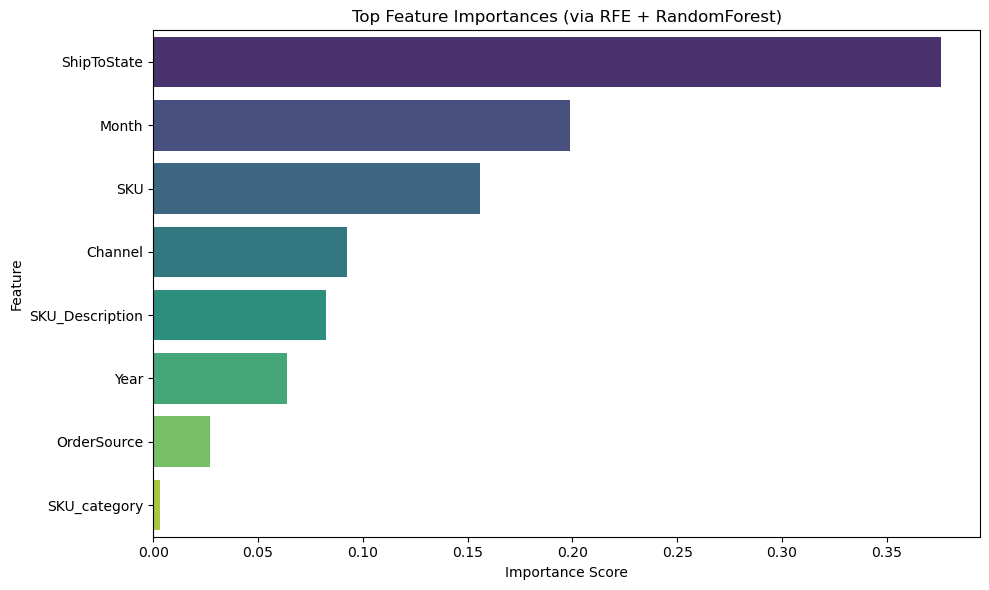

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns

# Drop target, order_id, and datetime columns from features
X = df_encoded.drop(['WareHouseQuanity', 'OrderDate', 'Week', 'order_id'], axis=1)
y = df_encoded['WareHouseQuanity']

# Initialize Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Recursive Feature Elimination
rfe = RFE(model, n_features_to_select=8)  # You can change number of features here
rfe.fit(X, y)

# Get the selected features
selected_features = X.columns[rfe.support_]
print("Top selected features:")
print(selected_features)

# Train model on full dataset with selected features
model.fit(X[selected_features], y)

# Get feature importances
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Feature Importances (via RFE + RandomForest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [26]:
df_encoded.corr()

,ProductFamily,order_id,OrderDate,Channel,OrderSource,SKU,SKU_Description,ShipToState,WareHouseQuanity,SKU_category,Week,Month,Year
ProductFamily,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,NaN,1.000000,-0.017232,-0.198721,0.035076,0.027430,0.022641,0.008998,-0.043130,0.050516,-0.017169,-0.044605,0.003330
OrderDate,NaN,-0.017232,1.000000,-0.088269,-0.047078,0.079756,0.043777,-0.034697,0.009303,0.055860,0.999965,-0.095678,0.917193
Channel,NaN,-0.198721,-0.088269,1.000000,0.457353,-0.005559,-0.018176,0.043535,-0.019253,0.006617,-0.088702,0.145900,-0.136930
OrderSource,NaN,0.035076,-0.047078,0.457353,1.000000,-0.074024,-0.083764,0.077798,-0.077814,-0.044405,-0.047803,0.095680,-0.080051
SKU,NaN,0.027430,0.079756,-0.005559,-0.074024,1.000000,0.828926,-0.030338,-0.129362,0.890371,0.079754,-0.034311,0.083876
SKU_Description,NaN,0.022641,0.043777,-0.018176,-0.083764,0.828926,1.000000,-0.034475,-0.094930,0.844012,0.043780,-0.045554,0.056860
ShipToState,NaN,0.008998,-0.034697,0.043535,0.077798,-0.030338,-0.034475,1.000000,-0.014581,-0.020811,-0.034730,0.070817,-0.058745
WareHouseQuanity,NaN,-0.043130,0.009303,-0.019253,-0.077814,-0.129362,-0.094930,-0.014581,1.000000,-0.122938,0.009389,-0.000331,0.008222
SKU_category,NaN,0.050516,0.055860,0.006617,-0.044405,0.890371,0.844012,-0.020811,-0.122938,1.000000,0.055873,-0.036245,0.063600


### Step 1: Get the Max Date and Calculate the Split Point

In [27]:
# # Ensure 'Week' is datetime
# df_encoded['Week'] = pd.to_datetime(df_encoded['Week'])

# # Get the latest date in the data
# max_date = df_encoded['Week'].max()

# # Calculate the split date (1 year before max date)
# split_date = max_date - pd.DateOffset(years=1)
# print(f"Split date: {split_date}")


### Step 2: Time-Based Split

In [28]:
# # Train = before split date, Test = 1 year from split date onward
# train = df_encoded[df_encoded['Week'] < split_date]
# test = df_encoded[df_encoded['Week'] >= split_date]


In [29]:
import pandas as pd

# Assuming your dataframe is already processed and contains a 'Week' column in datetime format
df_encoded['Week'] = pd.to_datetime(df_encoded['Week'])

# Set the test start date as the last available month minus 1 month
max_date = df_encoded['Week'].max()
test_start_date = max_date - pd.DateOffset(weeks=4)  # ~1 month = 4 weeks

# Split the data
train = df_encoded[df_encoded['Week'] < test_start_date]
test = df_encoded[df_encoded['Week'] >= test_start_date]

print("Max date:", max_date)
print("Train range:", train['Week'].min(), "to", train['Week'].max())
print("Test range:", test['Week'].min(), "to", test['Week'].max())


Max date: 2025-07-14 00:00:00
Train range: 2022-12-19 00:00:00 to 2025-06-09 00:00:00
Test range: 2025-06-16 00:00:00 to 2025-07-14 00:00:00


### Step 3: Define Features & Target

In [30]:
feature_cols = [
    'Channel', 'OrderSource',
    'SKU', 'ShipToState', 'SKU_category', 'Month', 'Year'
]

X_train = train[feature_cols]
y_train = train['WareHouseQuanity']

X_test = test[feature_cols]
y_test = test['WareHouseQuanity']


### Output Shapes

In [31]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train date range:", train['Week'].min(), "to", train['Week'].max())
print("Test date range:", test['Week'].min(), "to", test['Week'].max())


Train shape: (723035, 7)
Test shape: (32532, 7)
Train date range: 2022-12-19 00:00:00 to 2025-06-09 00:00:00
Test date range: 2025-06-16 00:00:00 to 2025-07-14 00:00:00


### Model Training for Forecasting
1) Random Forest Regressor

In [32]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [35]:

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)


In [36]:
y_pred

array([1.1658925 , 1.0455    , 1.03233333, ..., 1.54999567, 1.3163257 ,
       1.38381355])

In [37]:
# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance on Test Set:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


Model Performance on Test Set:
RMSE: 0.51
MAE: 0.26
R²: -0.08


#### GradientBoost Regressor

In [38]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [39]:
# Initialize the model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on test set
gb_pred = gb_model.predict(X_test)

In [40]:
gb_pred

array([1.13472001, 1.11272048, 1.21421795, ..., 1.42012638, 1.43133695,
       1.31288906])

In [41]:
# Evaluation Metrics
mse = mean_squared_error(y_test, gb_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, gb_pred)
r2 = r2_score(y_test, gb_pred)

print("Model Performance on Test Set:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


Model Performance on Test Set:
RMSE: 0.46
MAE: 0.26
R²: 0.11


### XGBoost Regressor

In [ ]:
# pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.8/150.0 MB 9.1 MB/s eta 0:00:17
   - -------------------------------------- 4.2/150.0 MB 10.5 MB/s eta 0:00:14
   - -------------------------------------- 6.3/150.0 MB 10.2 MB/s eta 0:00:15
   -- ------------------------------------- 8.4/150.0 MB 9.8 MB/s eta 0:00:15
   -- ------------------------------------- 10.0/150.0 MB 9.3 MB/s eta 0:00:16
   --- ------------------------------------ 12.1/150.0 MB 9.3 MB/s eta 0:00:15
   --- ------------------------------------ 14.2/150.0 MB 9.5 MB/s eta 0:00:15
   ---- ----------------------------------- 16.3/150.0 MB 9.5 MB/s eta 0:00:15
   ---- ----------------------------------- 18.6/150.0 MB 9.7 MB/s eta 0:00:14
   ----- ---------------------------------- 21.0/150.0 MB 9.8 MB/s eta 0:00:14
   ------ --------------------------------- 23.3/150.0 MB 9.8 MB/s eta 0:00:13
   ------ --------------------------------- 25.2/150.0 MB 9.8 

In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize the XGBoost model
xgb_model = XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test set
xgb_pred = xgb_model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, xgb_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, xgb_pred)
r2 = r2_score(y_test, xgb_pred)

print("XGBoost Model Performance on Test Set:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


XGBoost Model Performance on Test Set:
RMSE: 0.46
MAE: 0.25
R²: 0.11


### Aggregate Weekly Sales
Create weekly summaries by SKU, Channel, and State:

In [33]:
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuanity'].sum().reset_index()
weekly_by_channel = df.groupby(['Week', 'Channel'])['WareHouseQuanity'].sum().reset_index()
weekly_by_state = df.groupby(['Week', 'ShipToState'])['WareHouseQuanity'].sum().reset_index()


Processing forecast for SKU: 10AD300GRF01


21:48:32 - cmdstanpy - INFO - Chain [1] start processing
21:48:34 - cmdstanpy - INFO - Chain [1] done processing


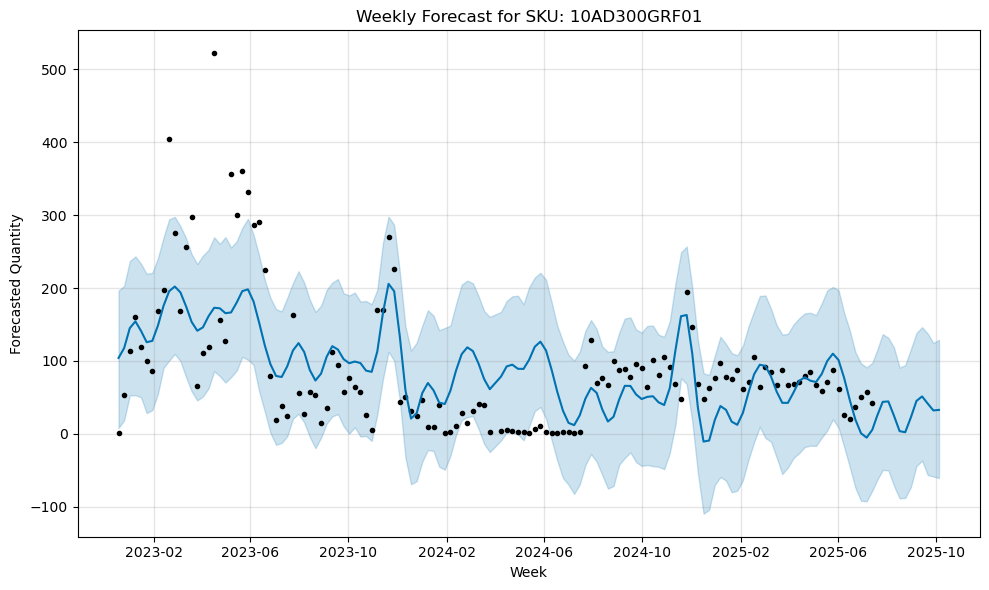

21:48:34 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD500GRF02


21:48:34 - cmdstanpy - INFO - Chain [1] done processing


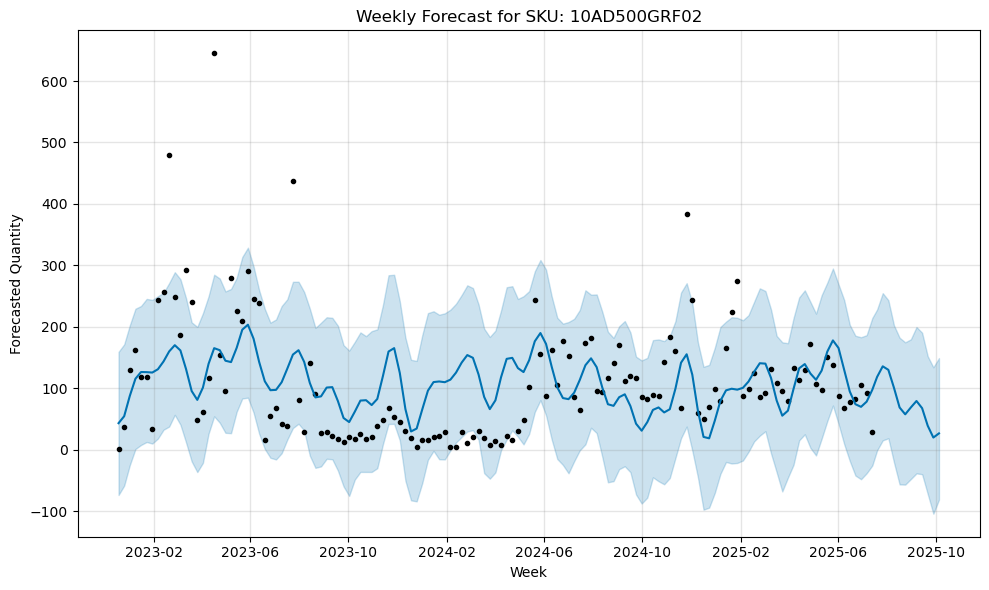

21:48:34 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD01TF01


21:48:34 - cmdstanpy - INFO - Chain [1] done processing


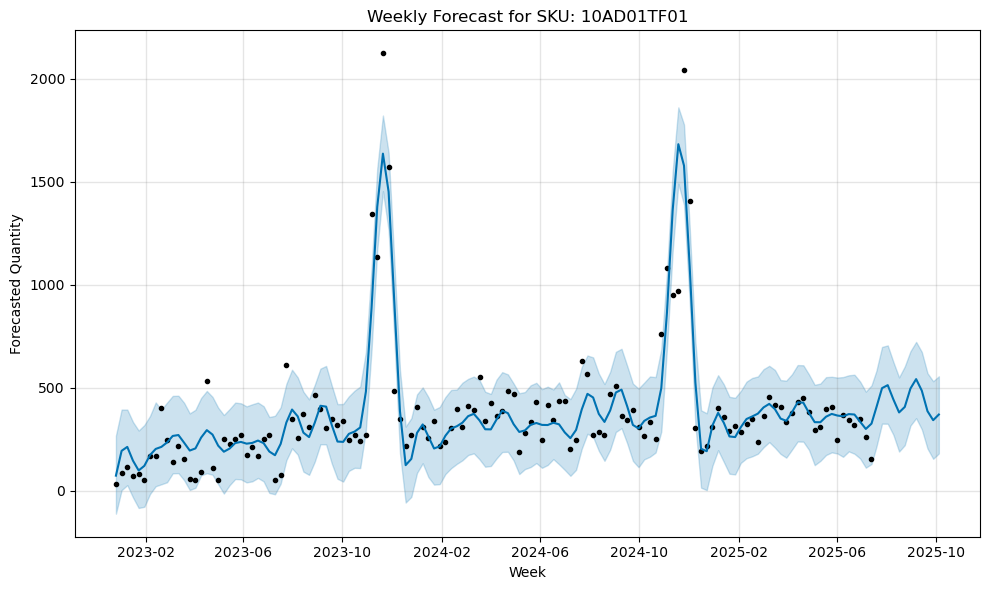

21:48:35 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD02CMPK1


21:48:35 - cmdstanpy - INFO - Chain [1] done processing


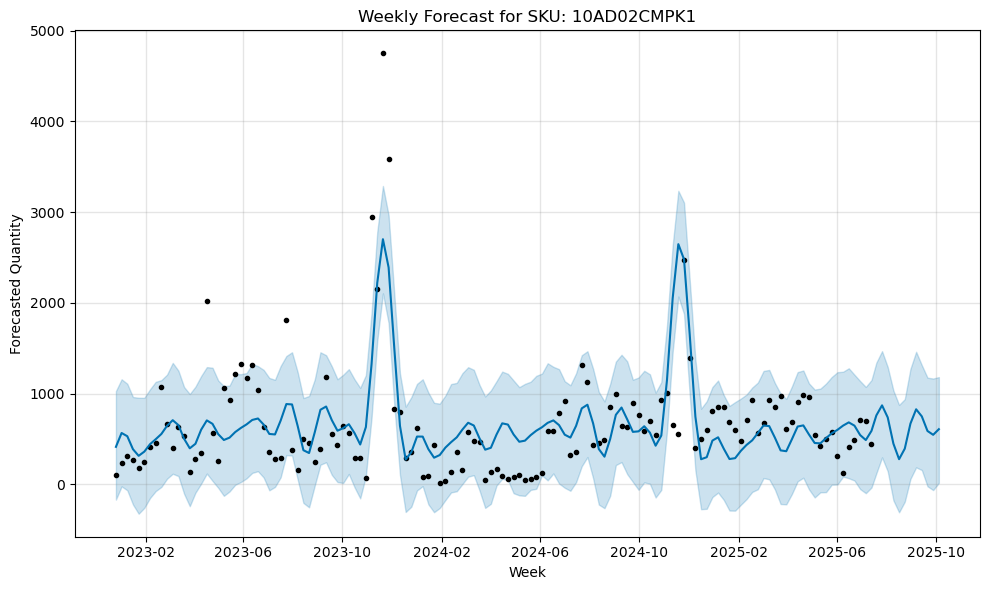

21:48:35 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD200CMPK1


21:48:35 - cmdstanpy - INFO - Chain [1] done processing


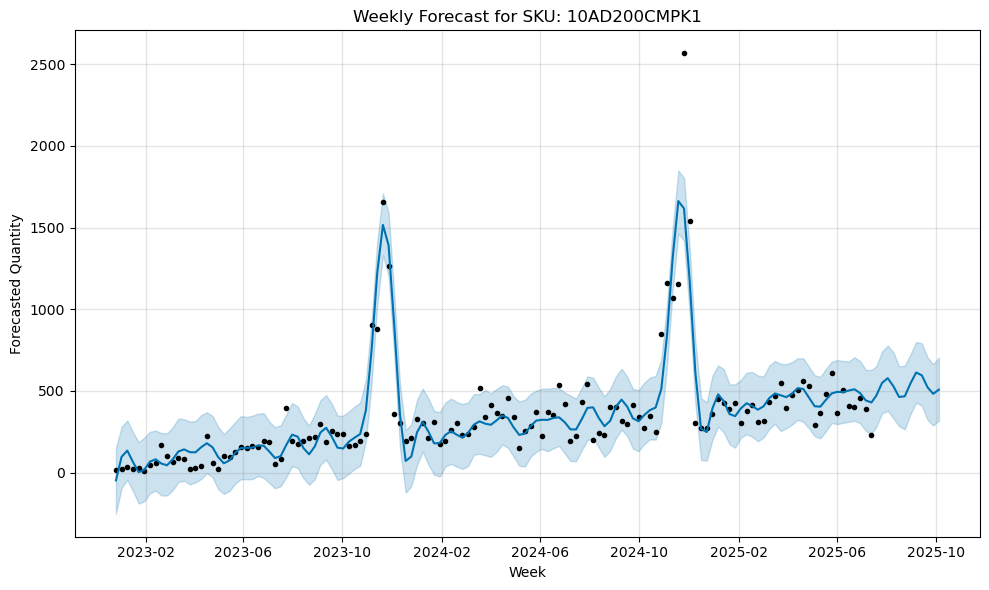

21:48:36 - cmdstanpy - INFO - Chain [1] start processing
21:48:36 - cmdstanpy - INFO - Chain [1] done processing


Processing forecast for SKU: 10AD200GRF01


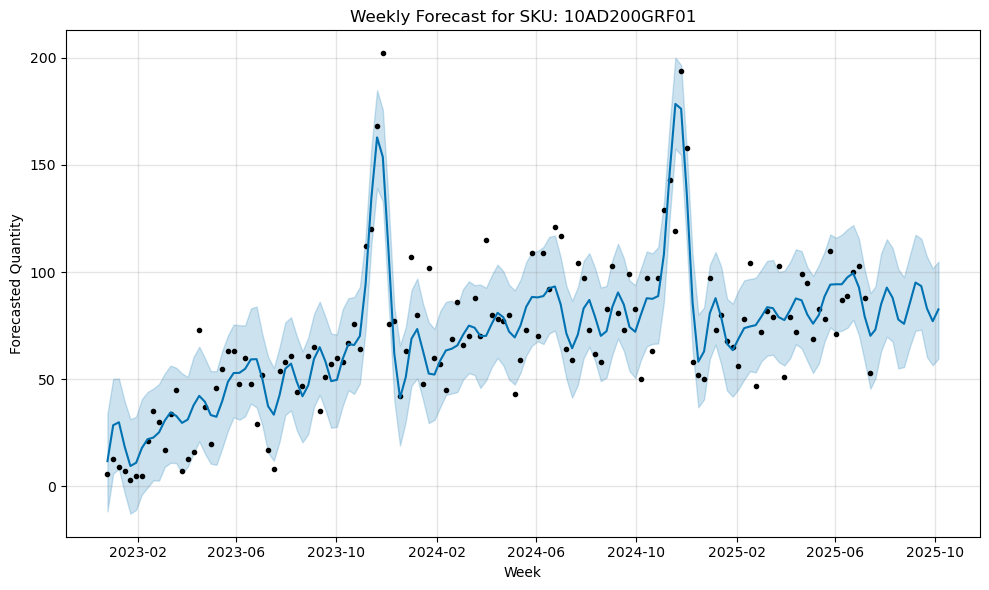

21:48:36 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD200HRF01


21:48:36 - cmdstanpy - INFO - Chain [1] done processing


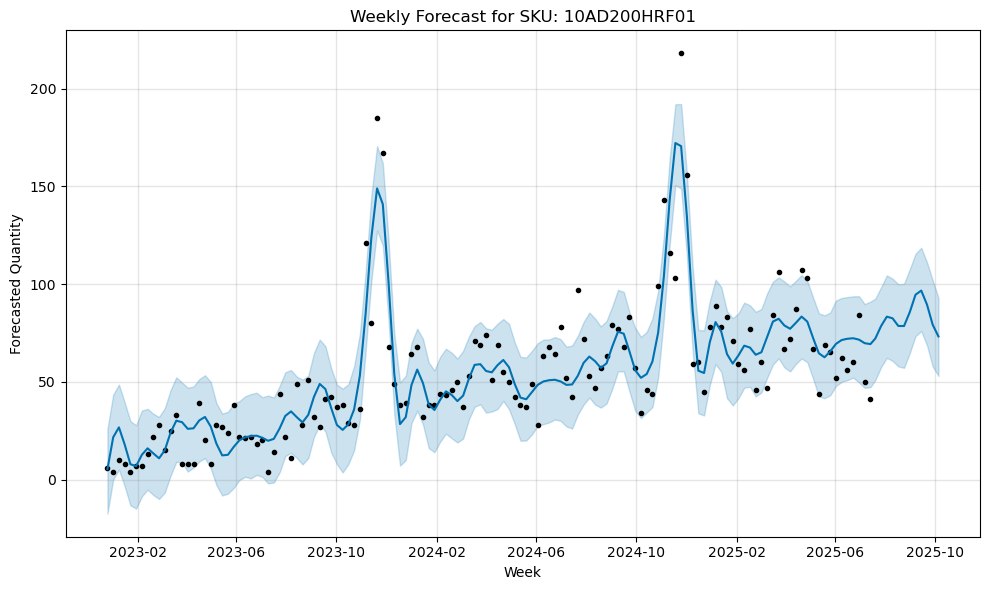

21:48:36 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD200PRF03


21:48:37 - cmdstanpy - INFO - Chain [1] done processing


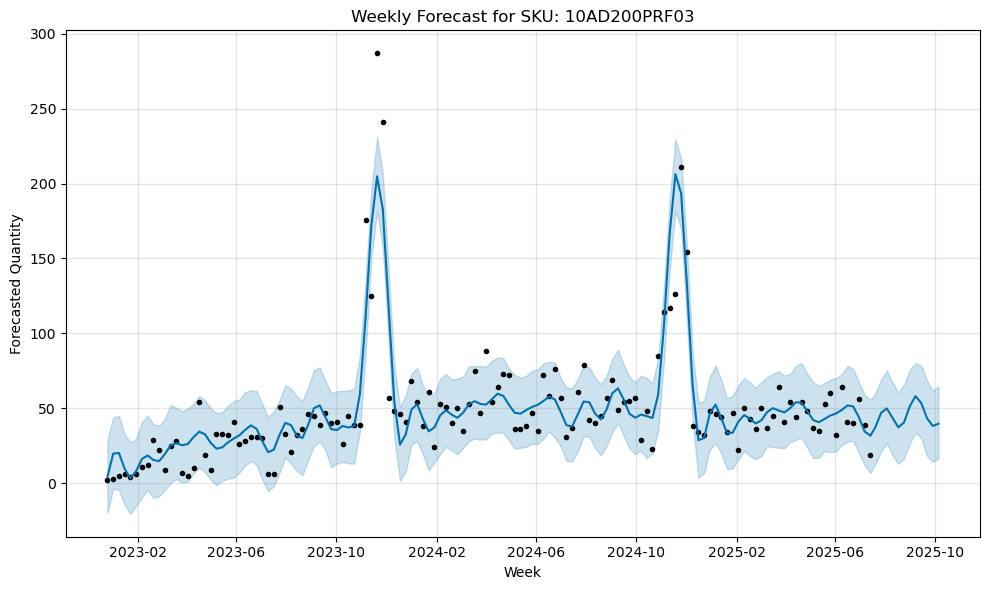

21:48:37 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD300HRF01


21:48:37 - cmdstanpy - INFO - Chain [1] done processing


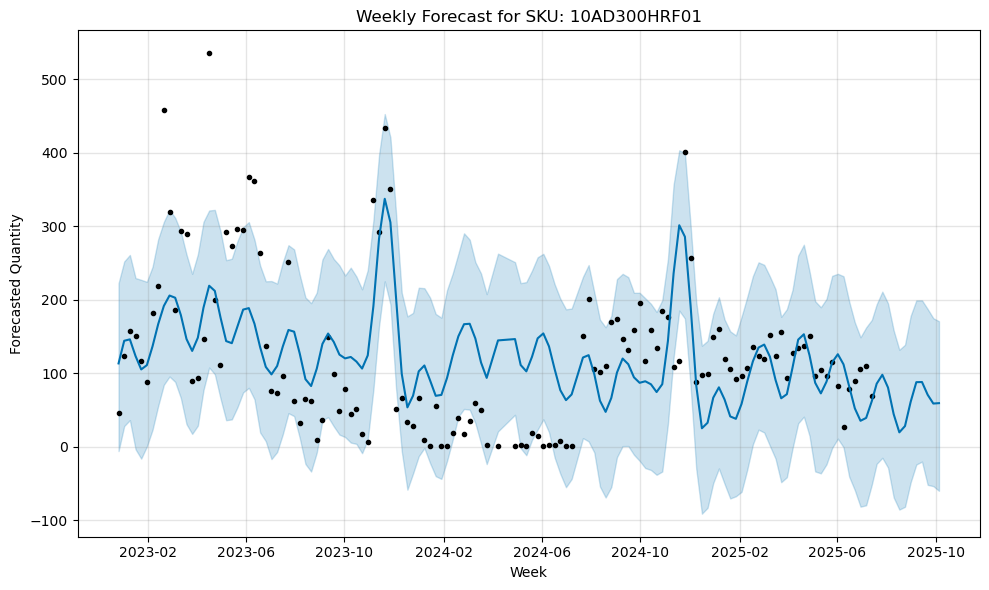

21:48:37 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD300PRF03


21:48:37 - cmdstanpy - INFO - Chain [1] done processing


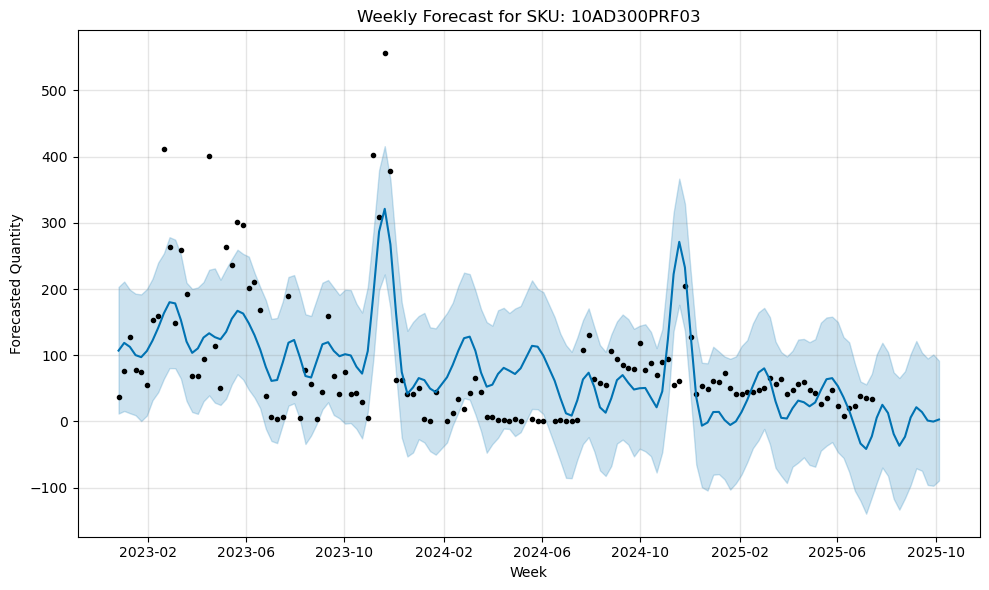

21:48:38 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD500PRF02


21:48:38 - cmdstanpy - INFO - Chain [1] done processing


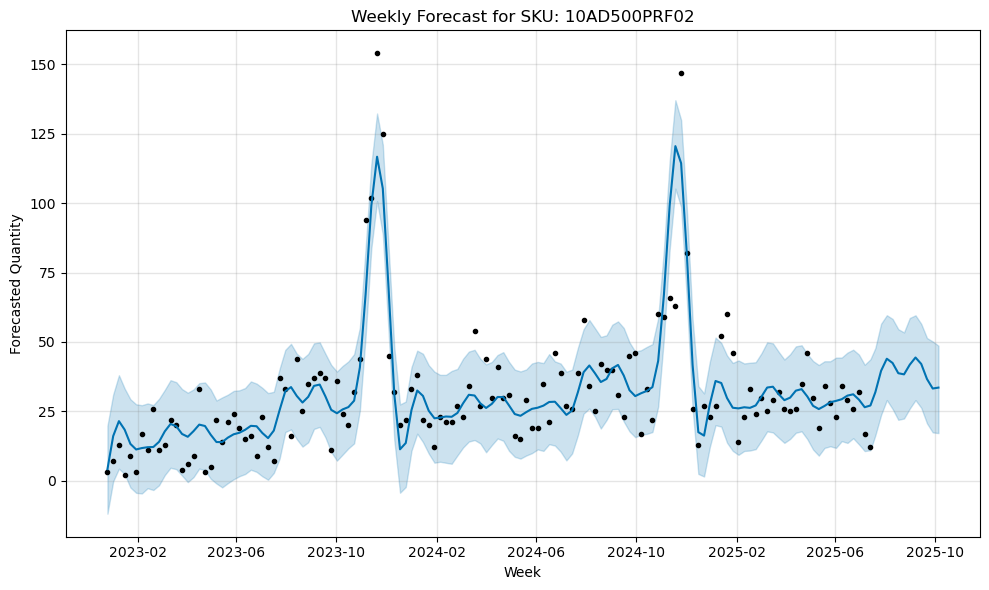

21:48:38 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD550HRF02


21:48:38 - cmdstanpy - INFO - Chain [1] done processing


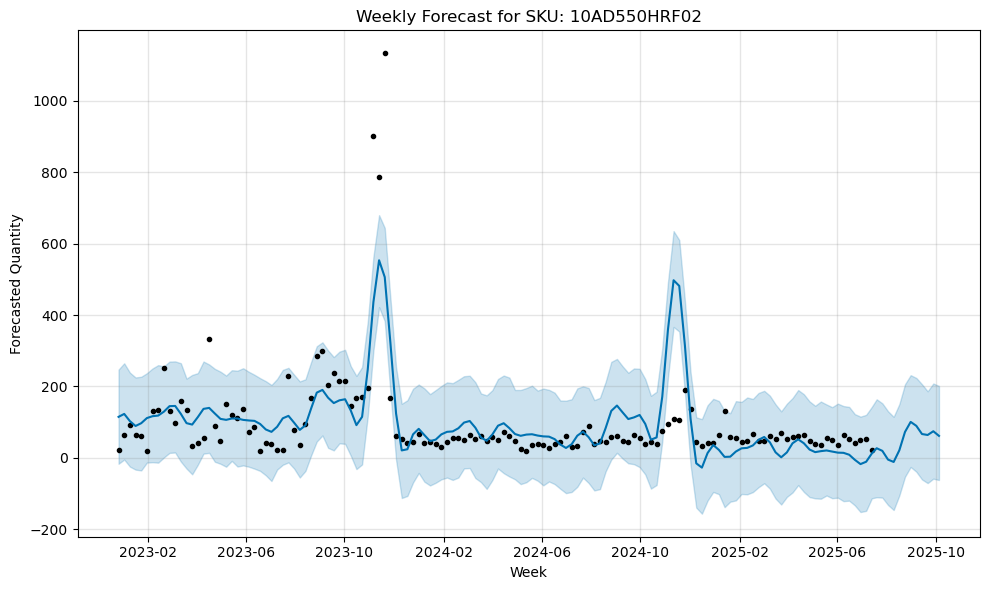

21:48:38 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B003


21:48:39 - cmdstanpy - INFO - Chain [1] done processing


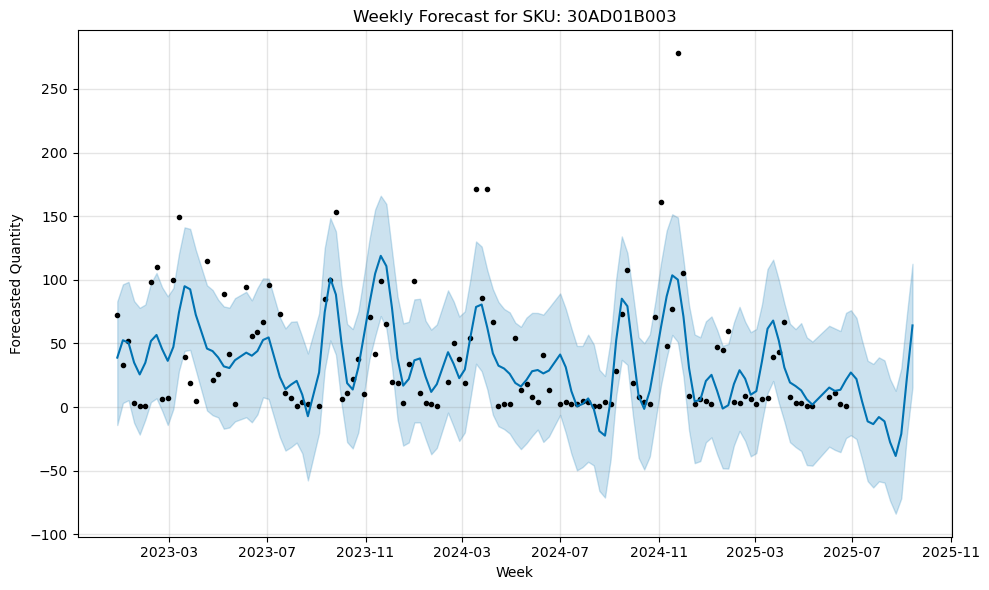

21:48:39 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD500CMPK1


21:48:39 - cmdstanpy - INFO - Chain [1] done processing


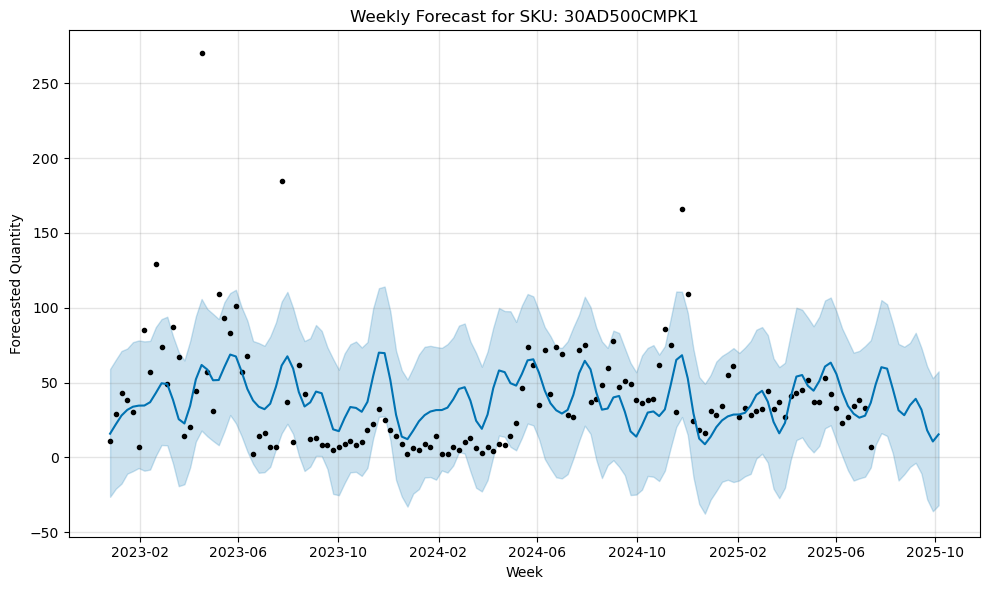

21:48:39 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD01TWC301


21:48:39 - cmdstanpy - INFO - Chain [1] done processing


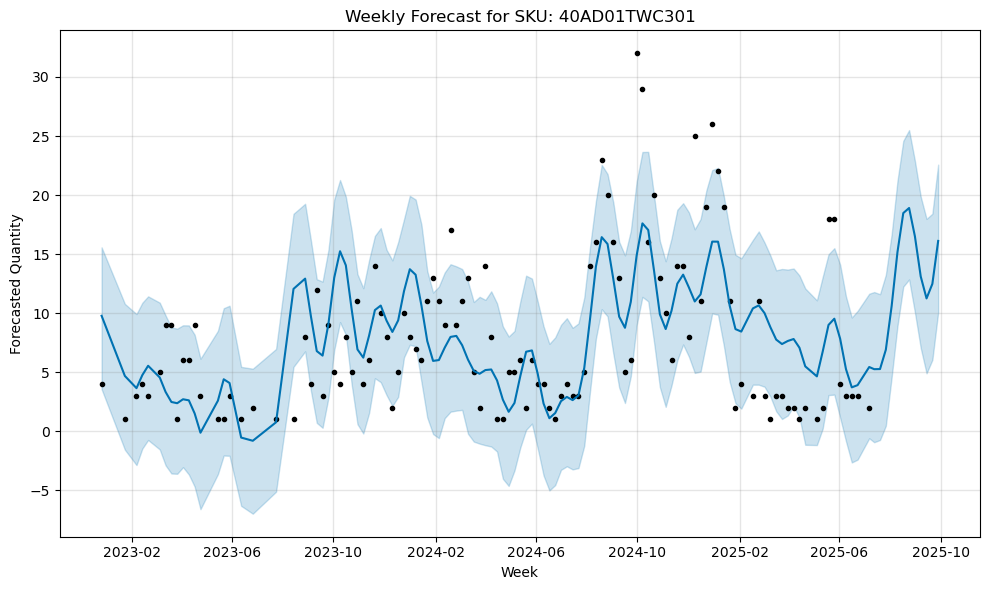

21:48:40 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD01WC301


21:48:40 - cmdstanpy - INFO - Chain [1] done processing


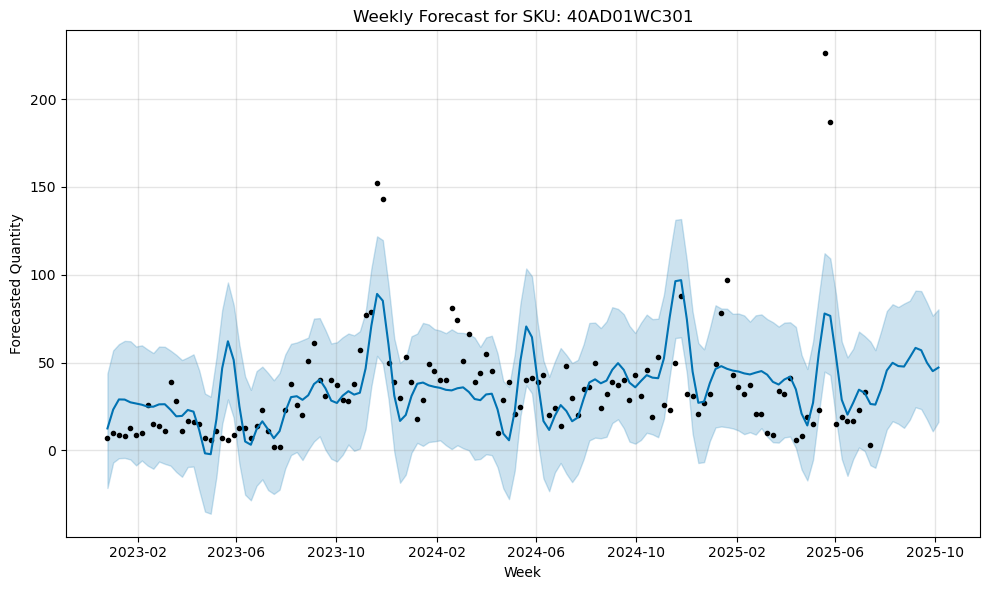

21:48:40 - cmdstanpy - INFO - Chain [1] start processing
21:48:40 - cmdstanpy - INFO - Chain [1] done processing


Processing forecast for SKU: 40AD02WC301


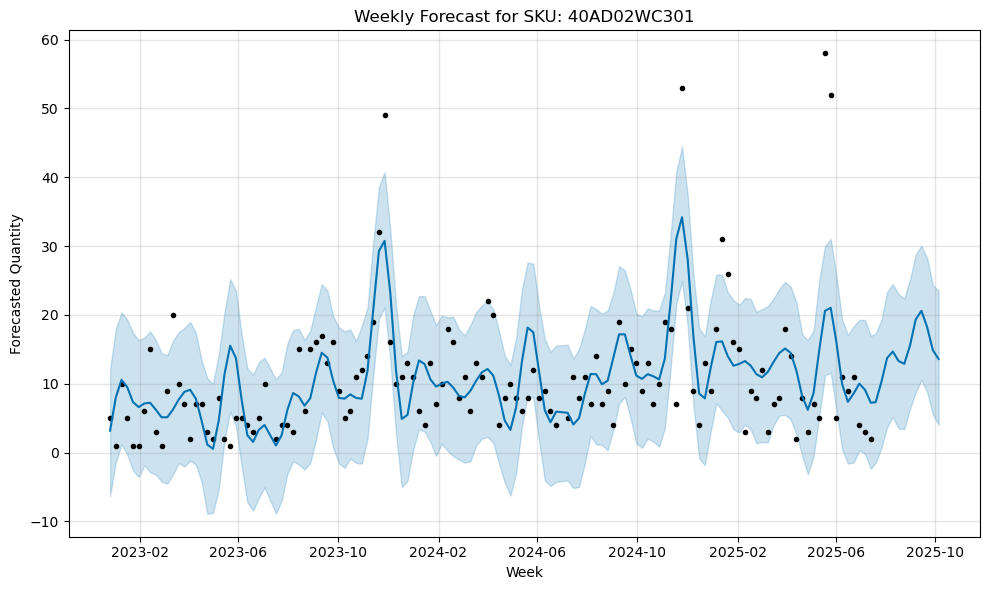

21:48:41 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD200WC301


21:48:41 - cmdstanpy - INFO - Chain [1] done processing


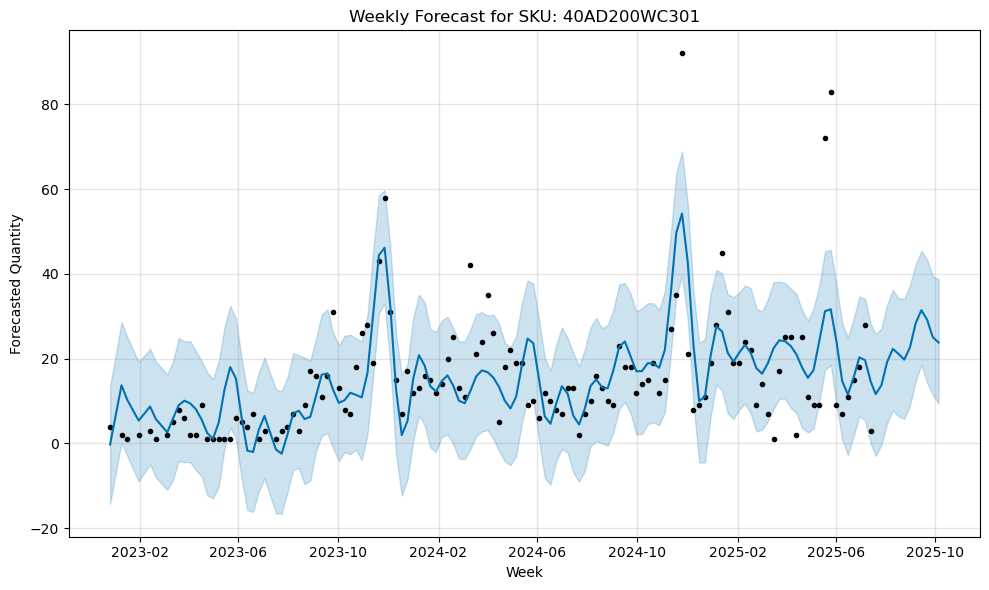

21:48:41 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD01AT01-W


21:48:41 - cmdstanpy - INFO - Chain [1] done processing


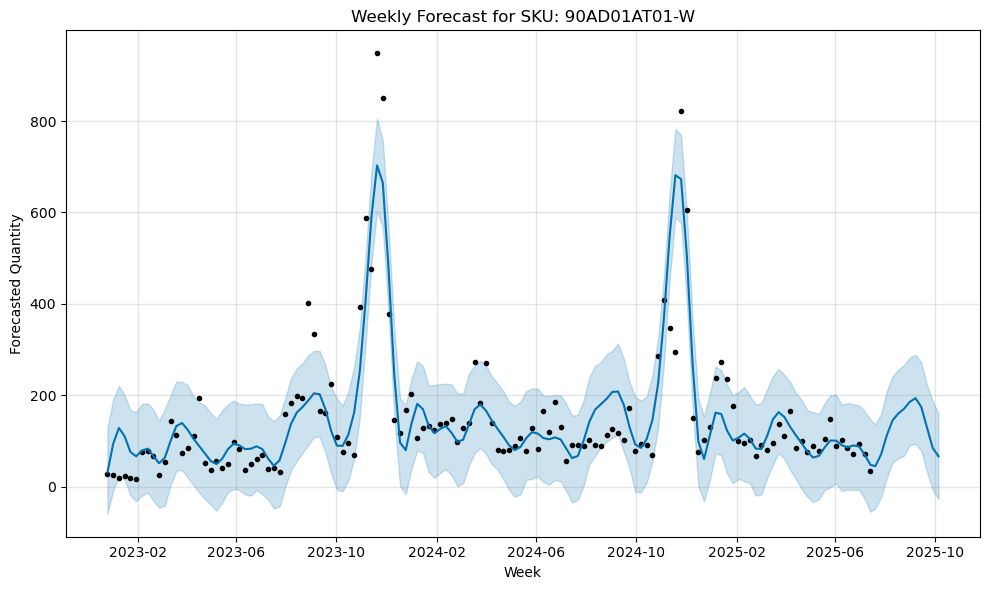

21:48:41 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD200AD01


21:48:41 - cmdstanpy - INFO - Chain [1] done processing


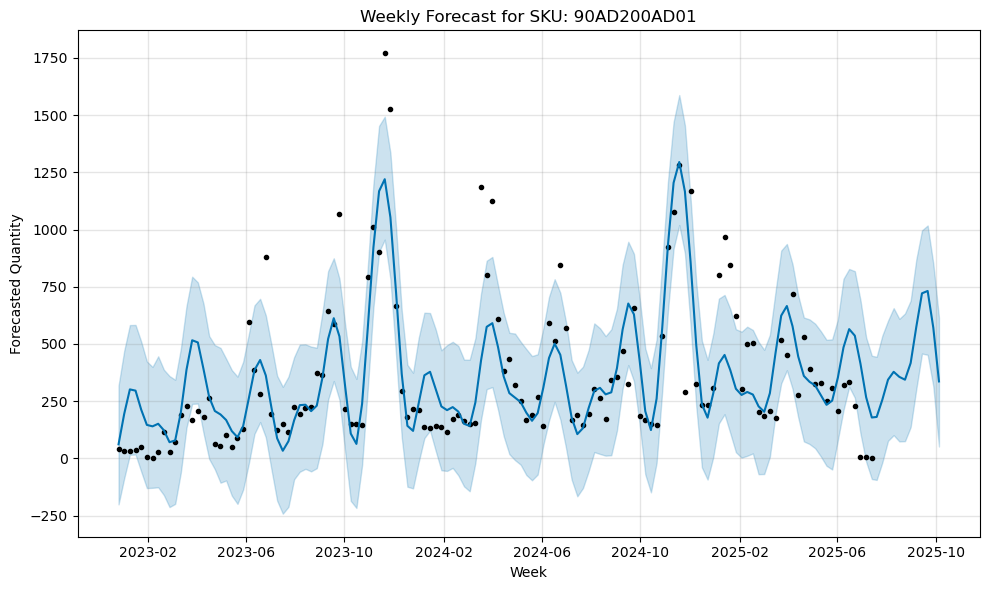

21:48:42 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD350AD01


21:48:42 - cmdstanpy - INFO - Chain [1] done processing


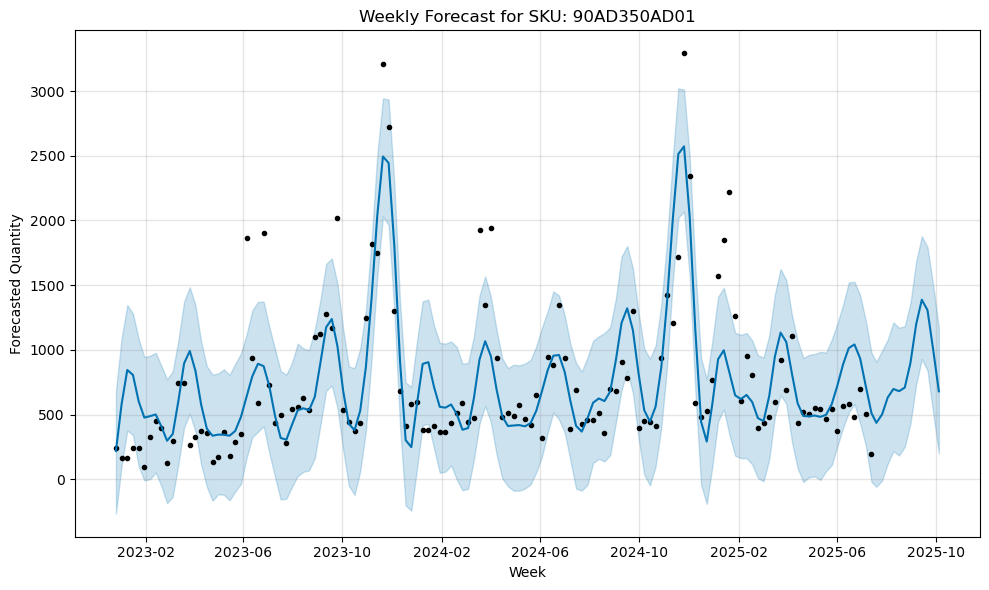

21:48:42 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD550AD01


21:48:42 - cmdstanpy - INFO - Chain [1] done processing


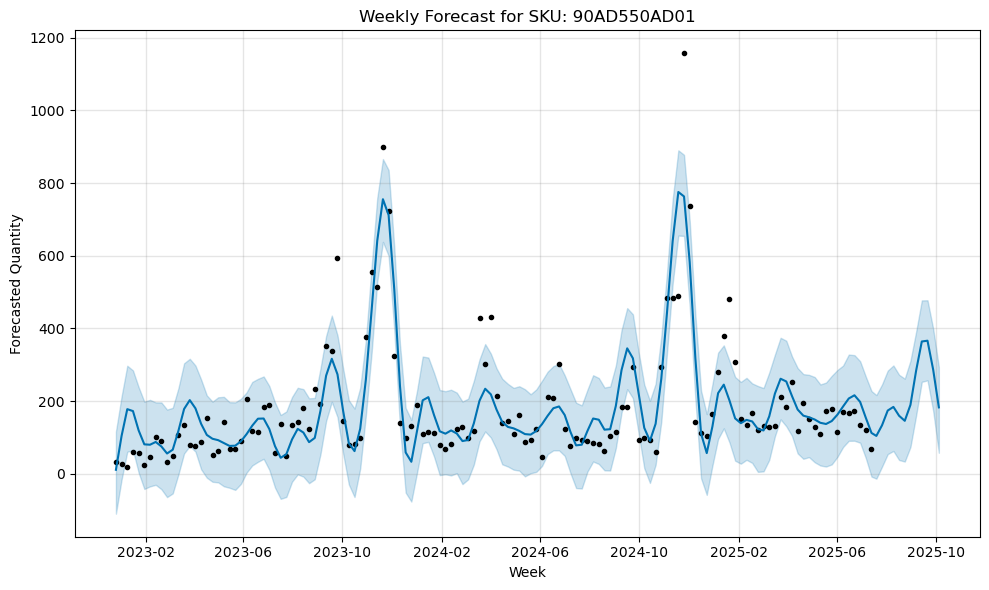

21:48:43 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD100MN01


21:48:43 - cmdstanpy - INFO - Chain [1] done processing


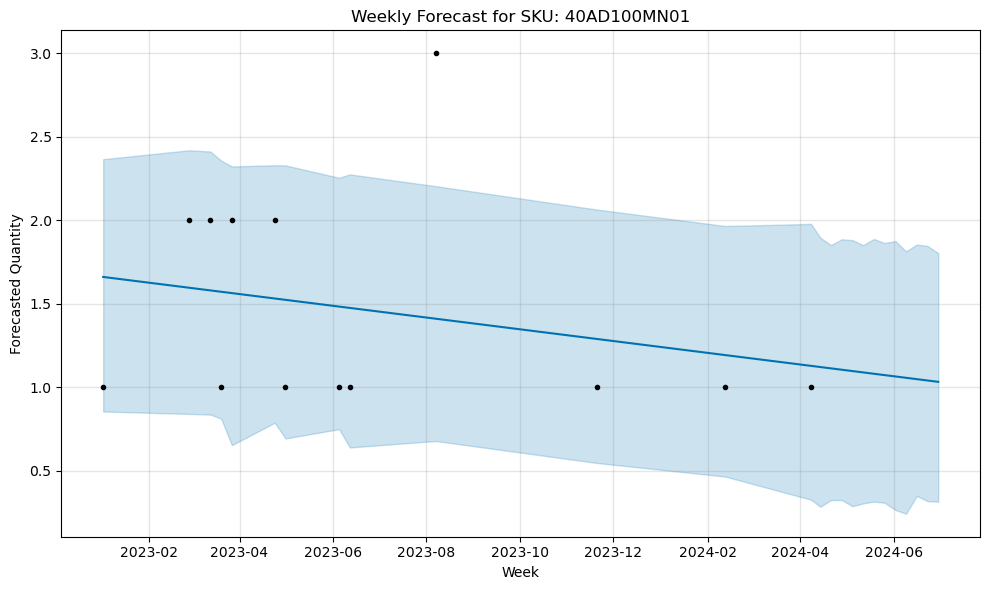

21:48:43 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD300MN01


21:48:43 - cmdstanpy - INFO - Chain [1] done processing


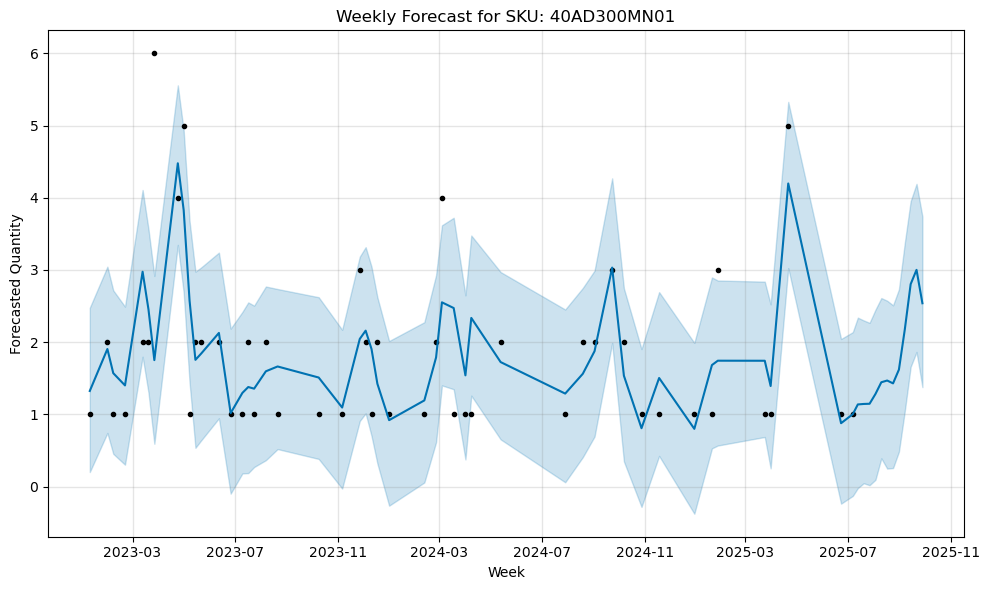

21:48:44 - cmdstanpy - INFO - Chain [1] start processing
21:48:44 - cmdstanpy - INFO - Chain [1] done processing


Processing forecast for SKU: 10AD01FNA02


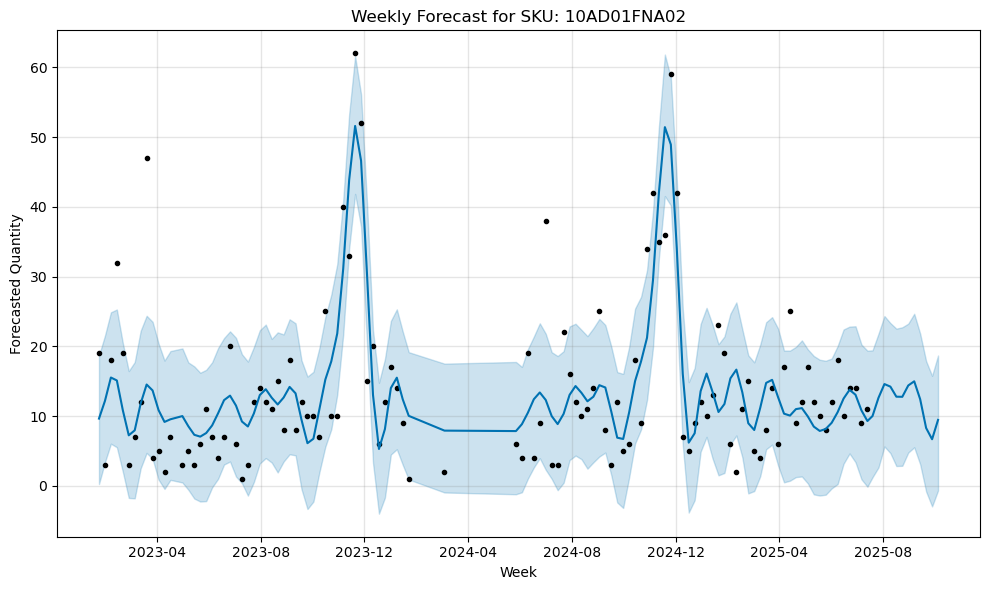

21:48:44 - cmdstanpy - INFO - Chain [1] start processing
21:48:44 - cmdstanpy - INFO - Chain [1] done processing


Processing forecast for SKU: 10AD01FNB02


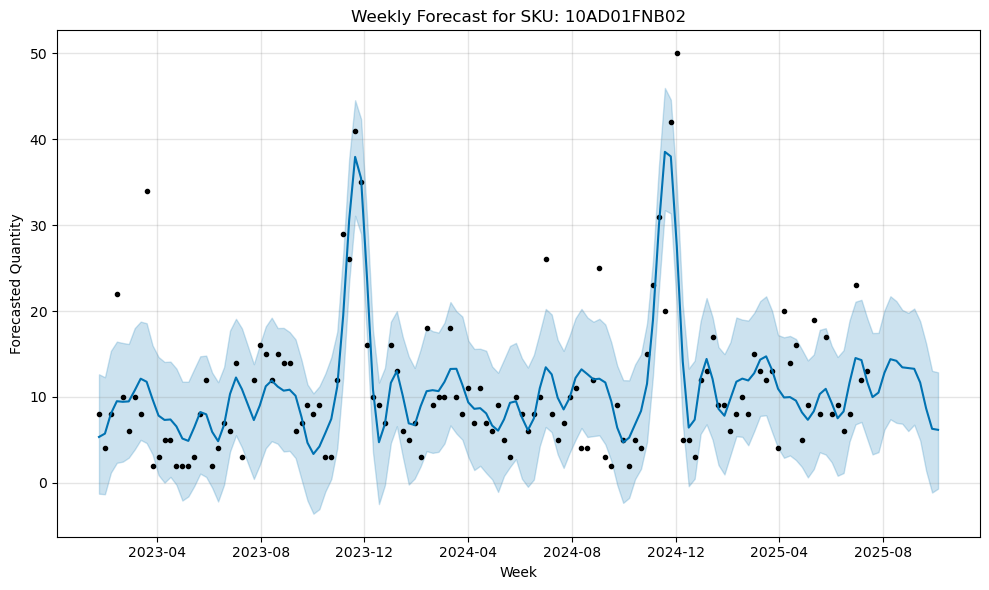

21:48:44 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD01FNC02


21:48:44 - cmdstanpy - INFO - Chain [1] done processing


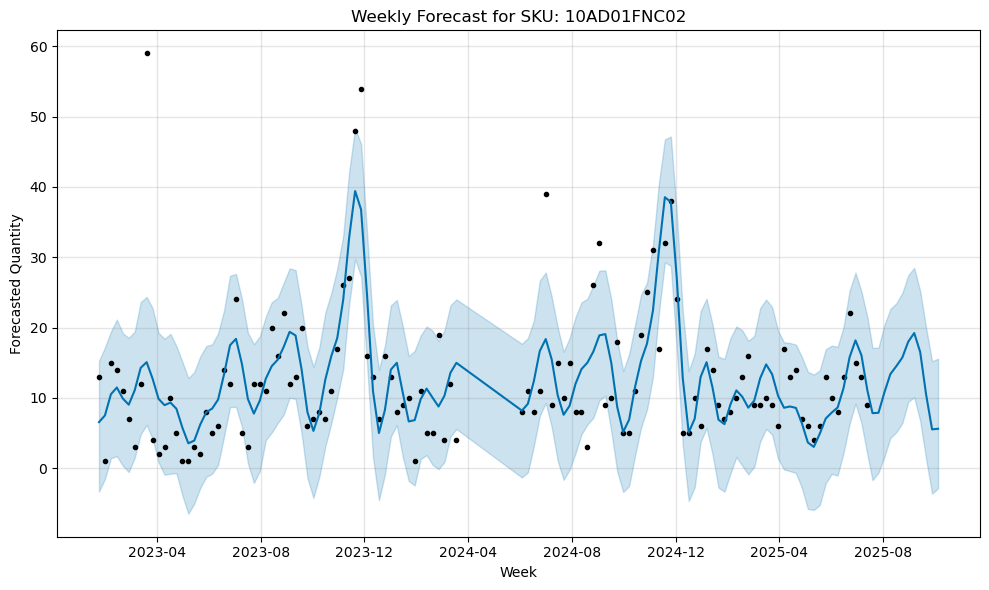

21:48:45 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD01FND02


21:48:45 - cmdstanpy - INFO - Chain [1] done processing


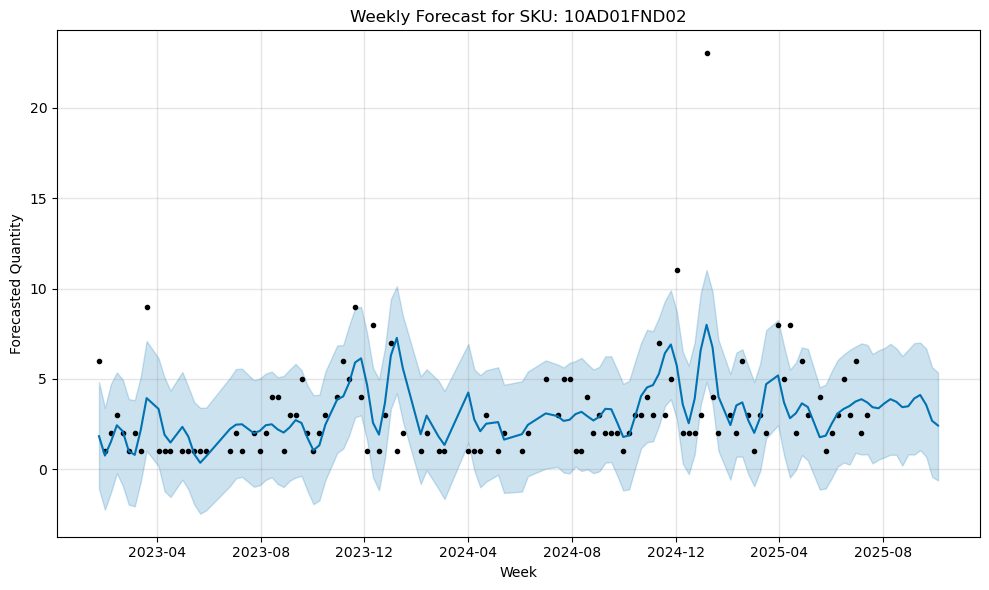

21:48:45 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD01FNE02


21:48:45 - cmdstanpy - INFO - Chain [1] done processing


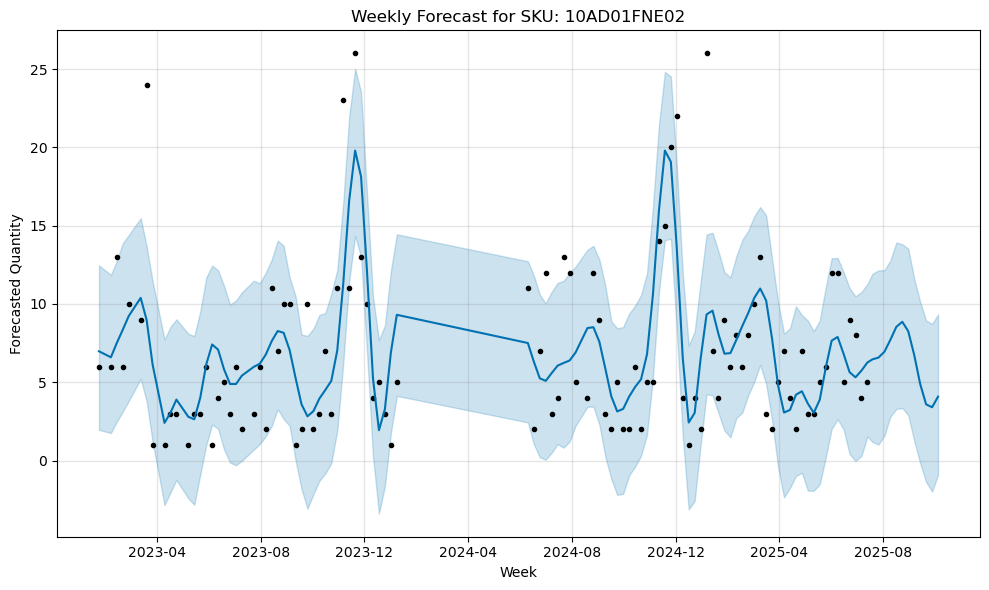

21:48:46 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD01FNF02


21:48:46 - cmdstanpy - INFO - Chain [1] done processing


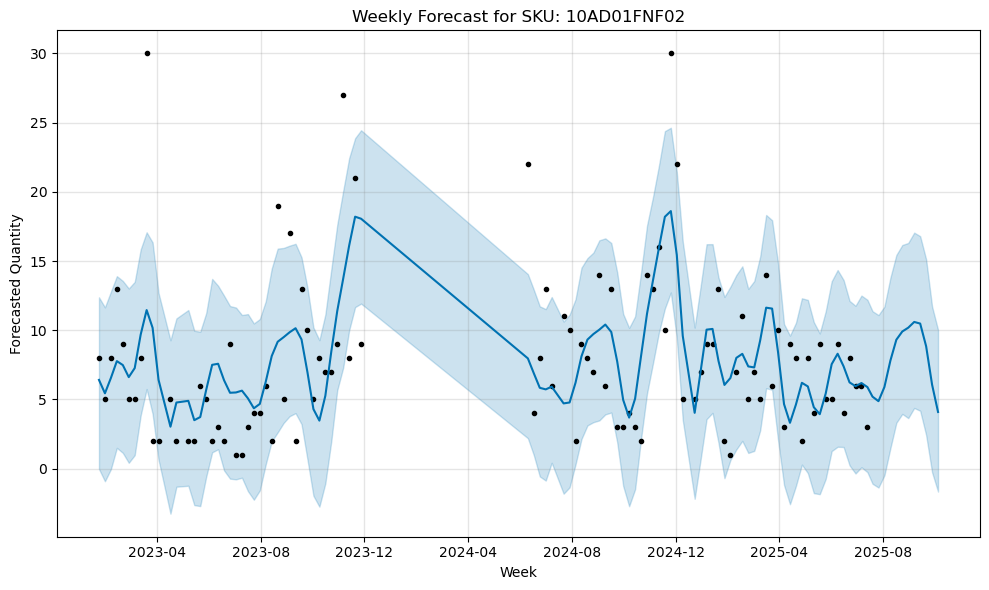

21:48:46 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD500MN01


21:48:47 - cmdstanpy - INFO - Chain [1] done processing


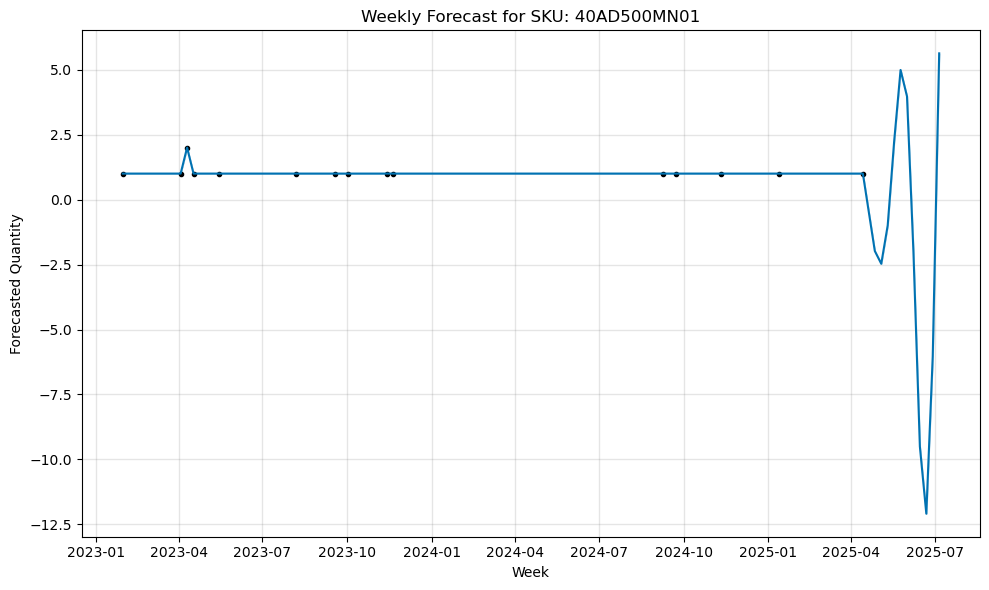

21:48:47 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD01PC01


21:48:47 - cmdstanpy - INFO - Chain [1] done processing


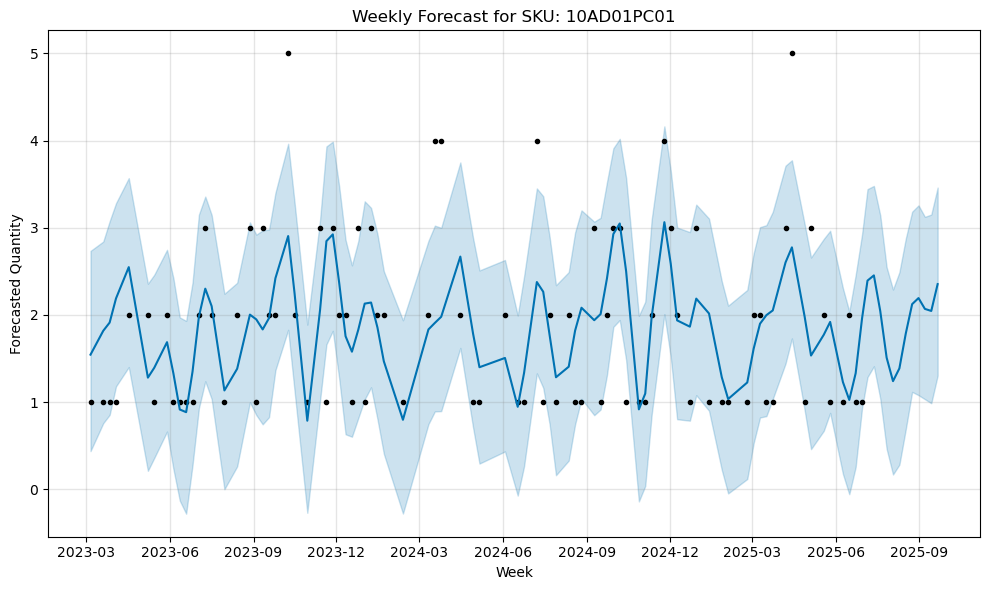

21:48:47 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B002


21:48:48 - cmdstanpy - INFO - Chain [1] done processing


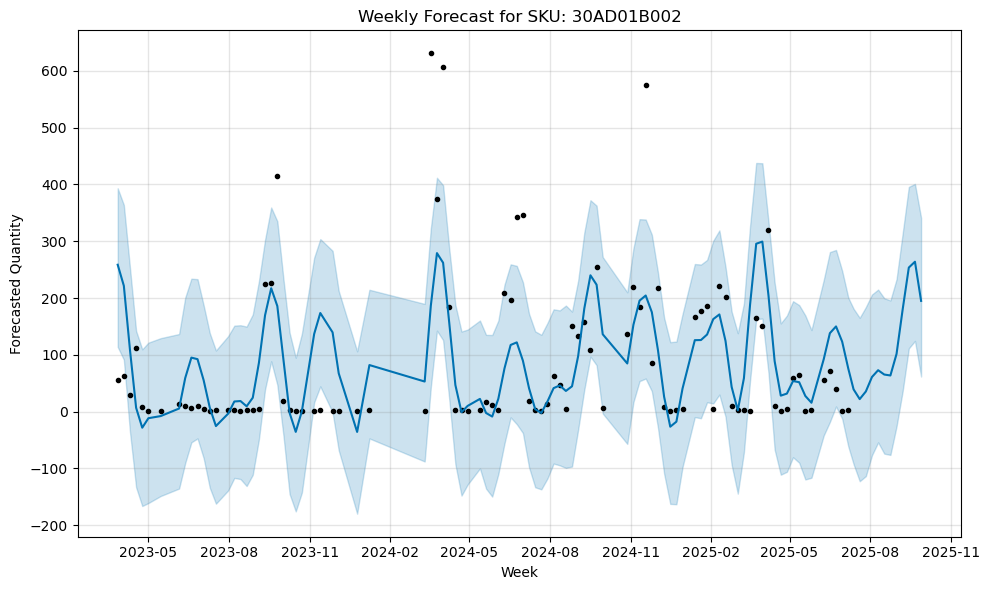

21:48:48 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B005


21:48:49 - cmdstanpy - INFO - Chain [1] done processing


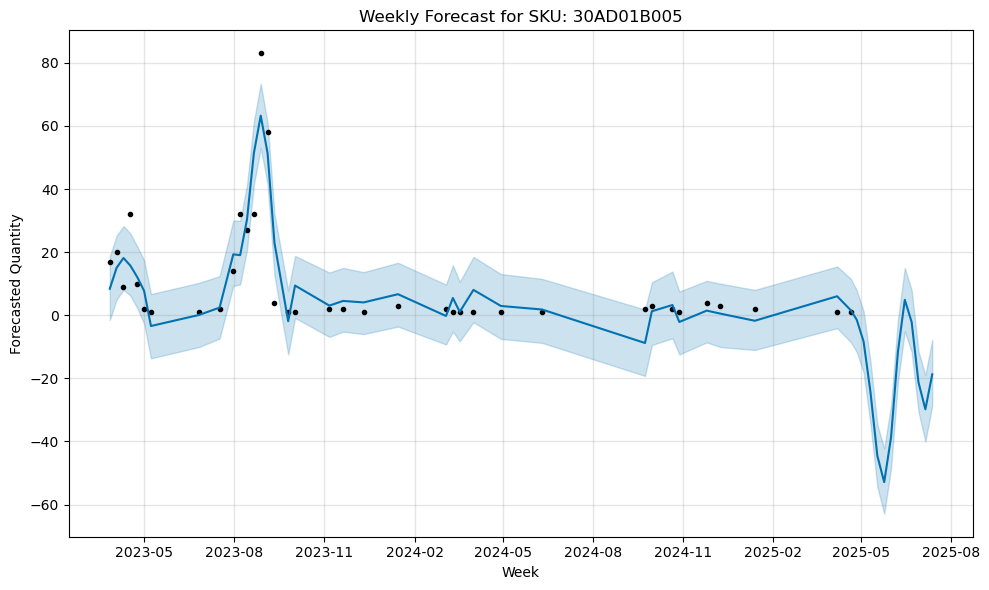

21:48:49 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B007


21:48:49 - cmdstanpy - INFO - Chain [1] done processing


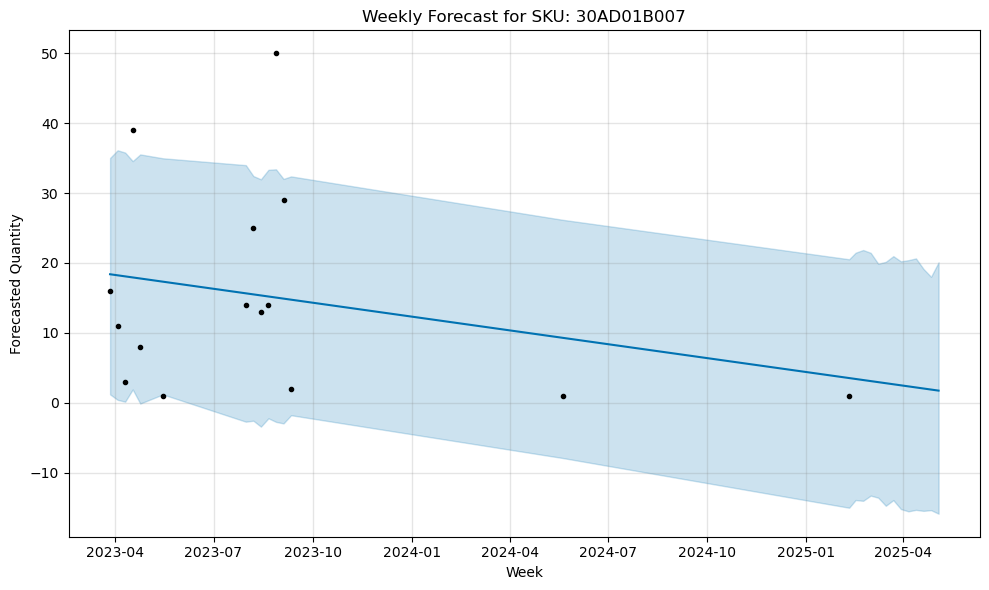

21:48:49 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B008


21:48:49 - cmdstanpy - INFO - Chain [1] done processing


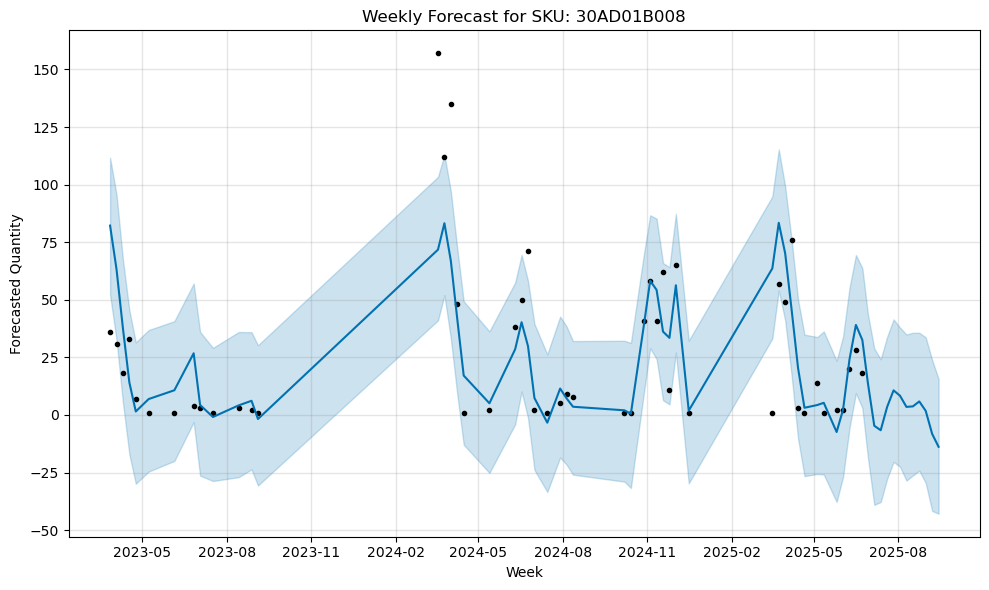

21:48:50 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD01TWC501


21:48:50 - cmdstanpy - INFO - Chain [1] done processing


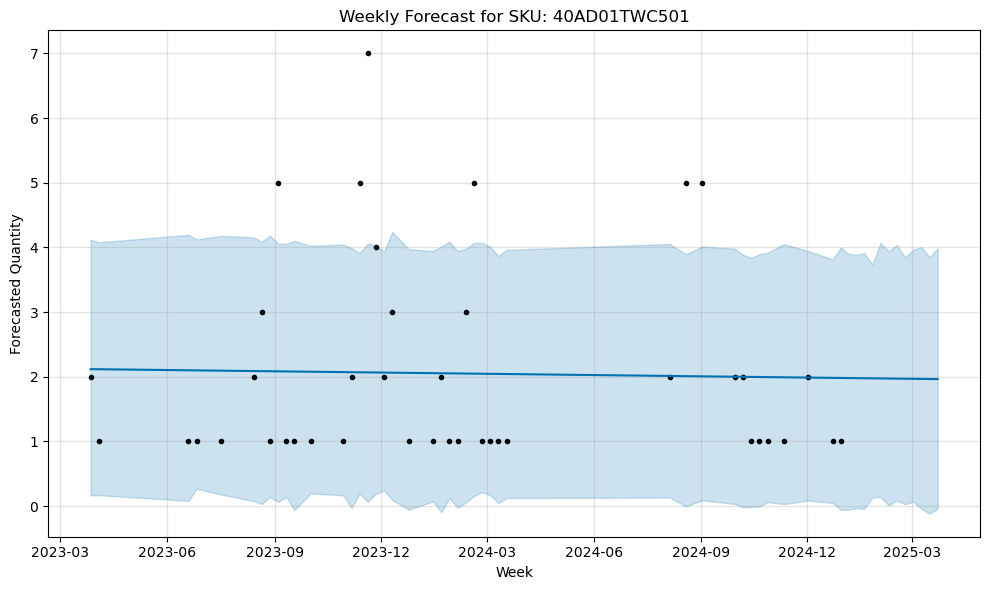

21:48:50 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD01WC501


21:48:51 - cmdstanpy - INFO - Chain [1] done processing


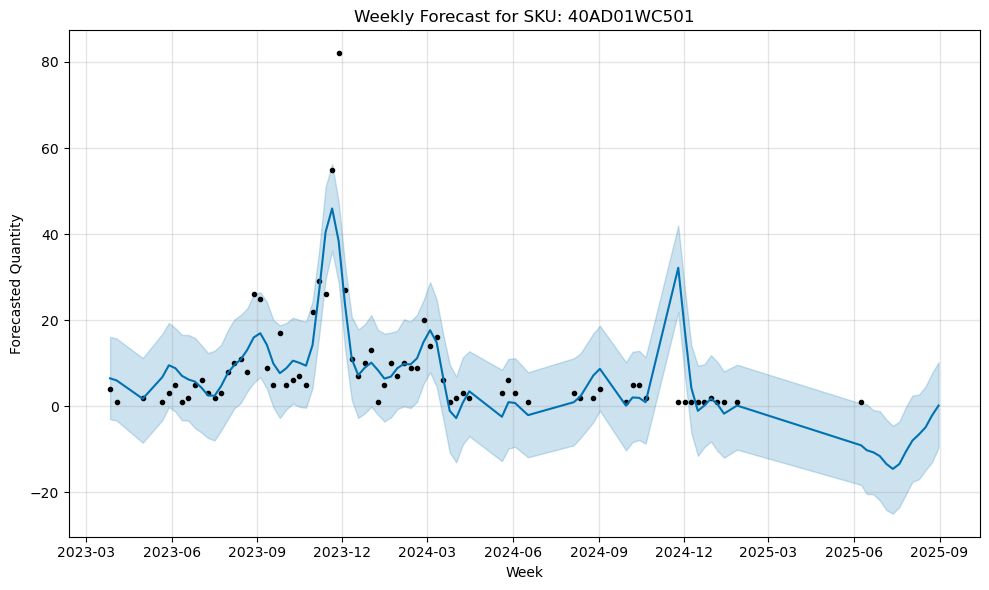

21:48:51 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD01AD01-HD


21:48:51 - cmdstanpy - INFO - Chain [1] done processing


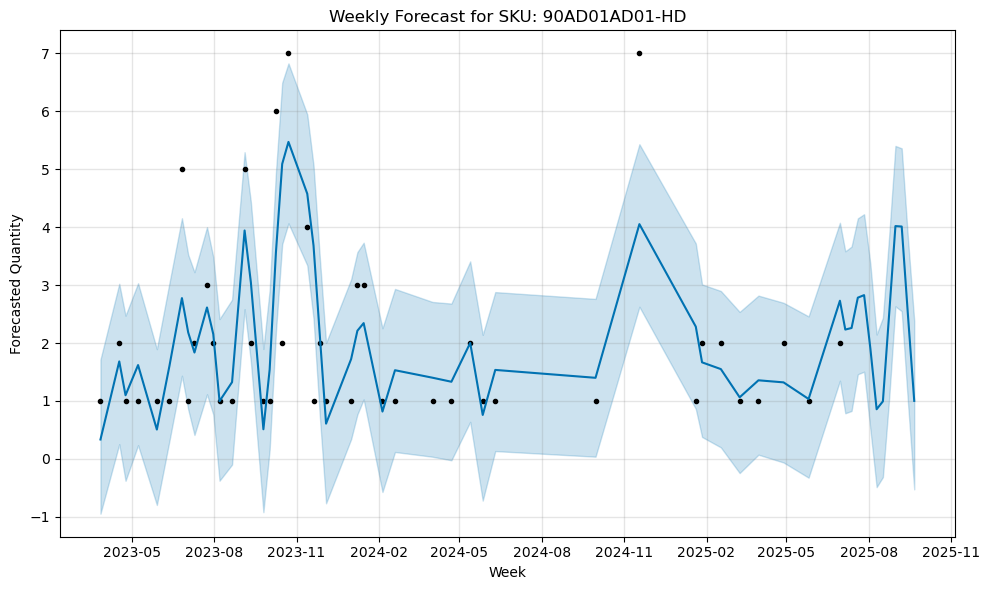

21:48:51 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD02WC501


21:48:52 - cmdstanpy - INFO - Chain [1] done processing


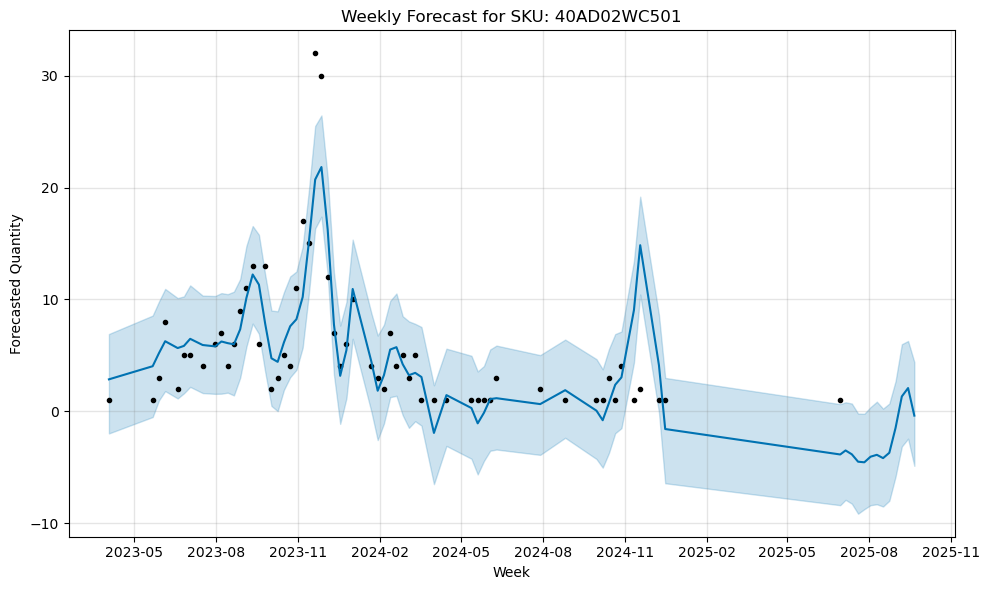

21:48:52 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B006


21:48:52 - cmdstanpy - INFO - Chain [1] done processing


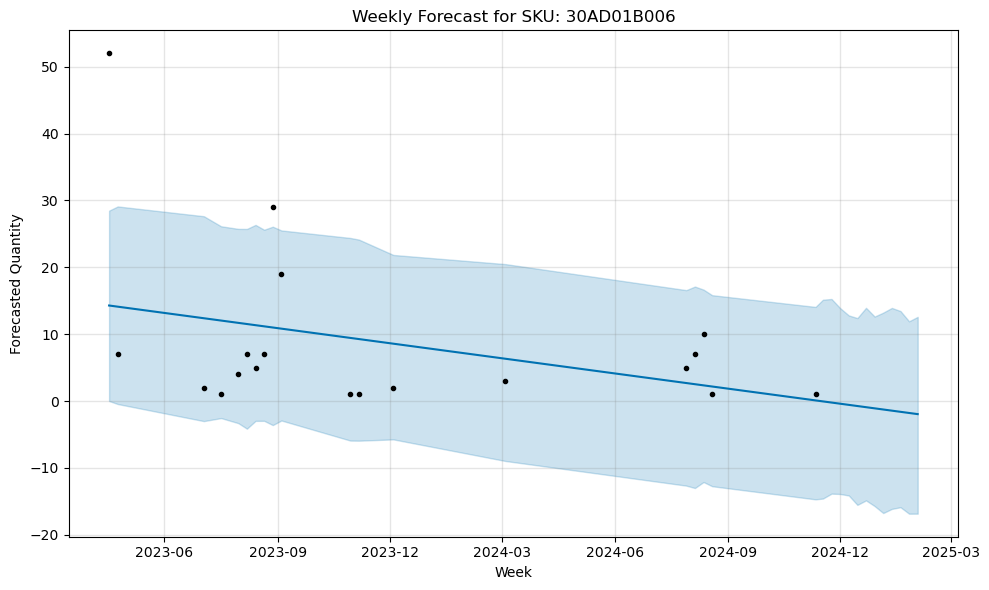

21:48:52 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD500HRF02


21:48:53 - cmdstanpy - INFO - Chain [1] done processing


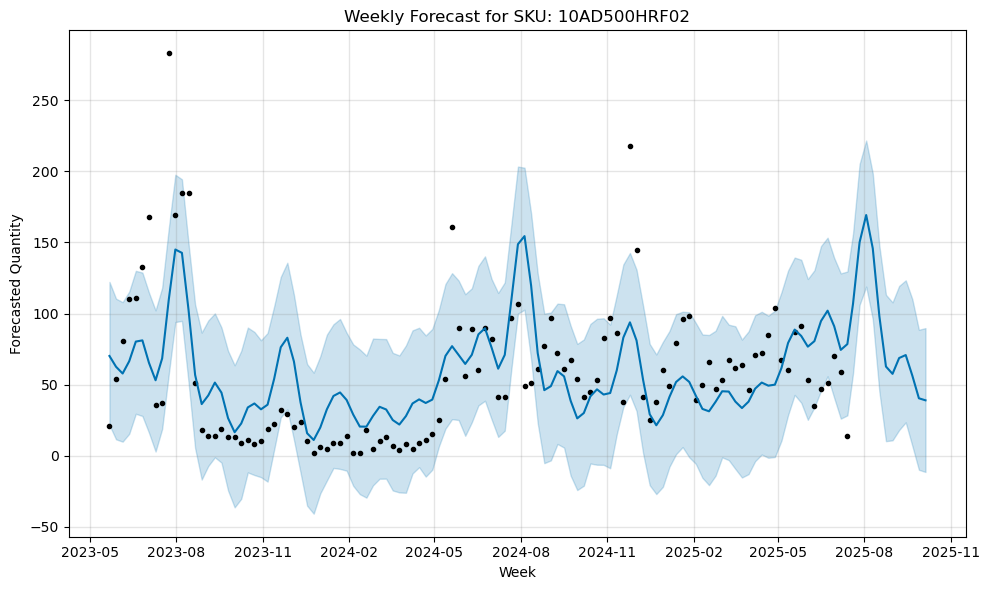

21:48:53 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD550CMPK1


21:48:53 - cmdstanpy - INFO - Chain [1] done processing


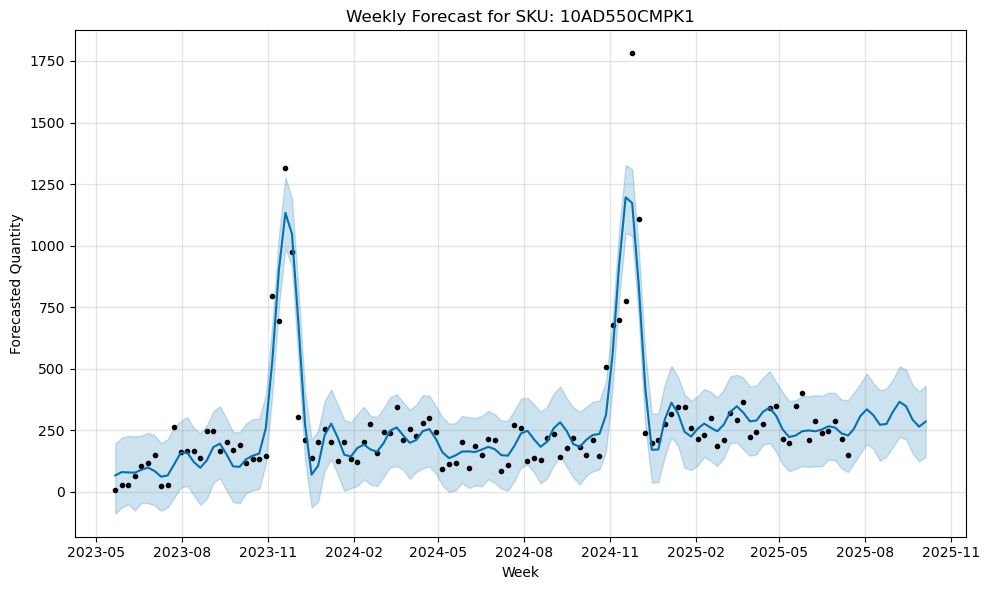

21:48:53 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD550GRF02


21:48:53 - cmdstanpy - INFO - Chain [1] done processing


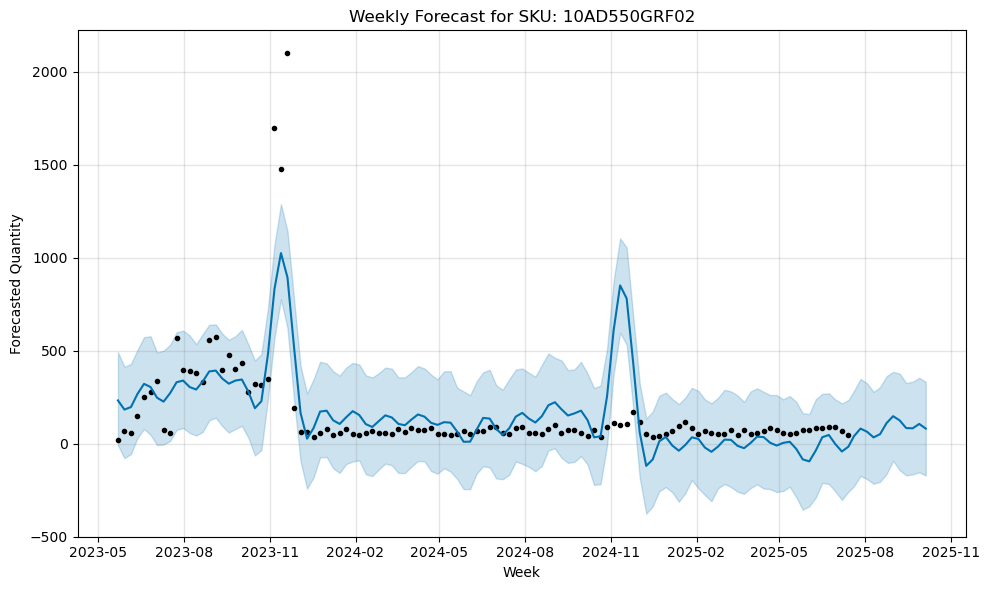

21:48:54 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD500AD01


21:48:54 - cmdstanpy - INFO - Chain [1] done processing


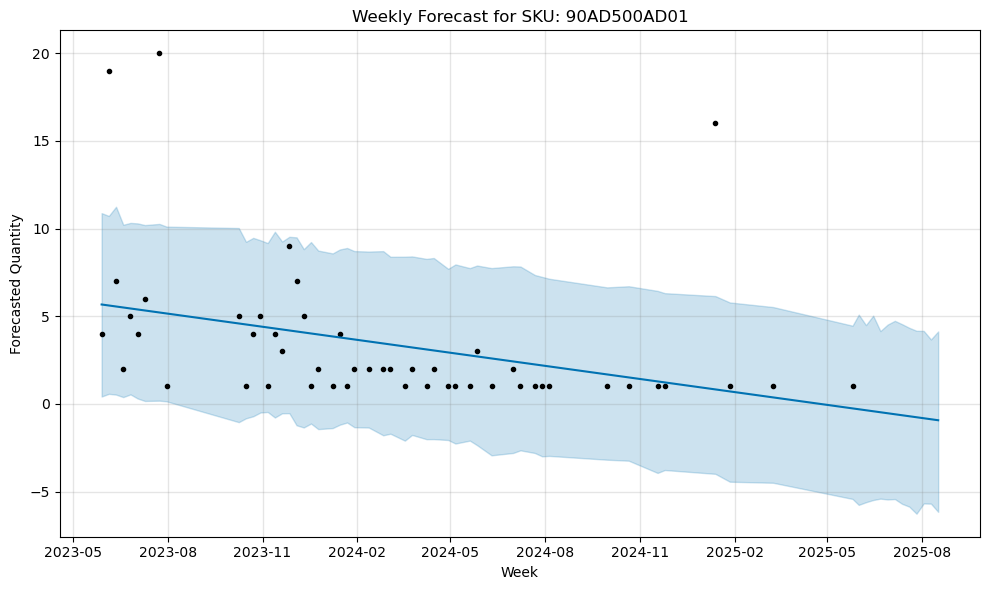

21:48:54 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD200WC501


21:48:55 - cmdstanpy - INFO - Chain [1] done processing


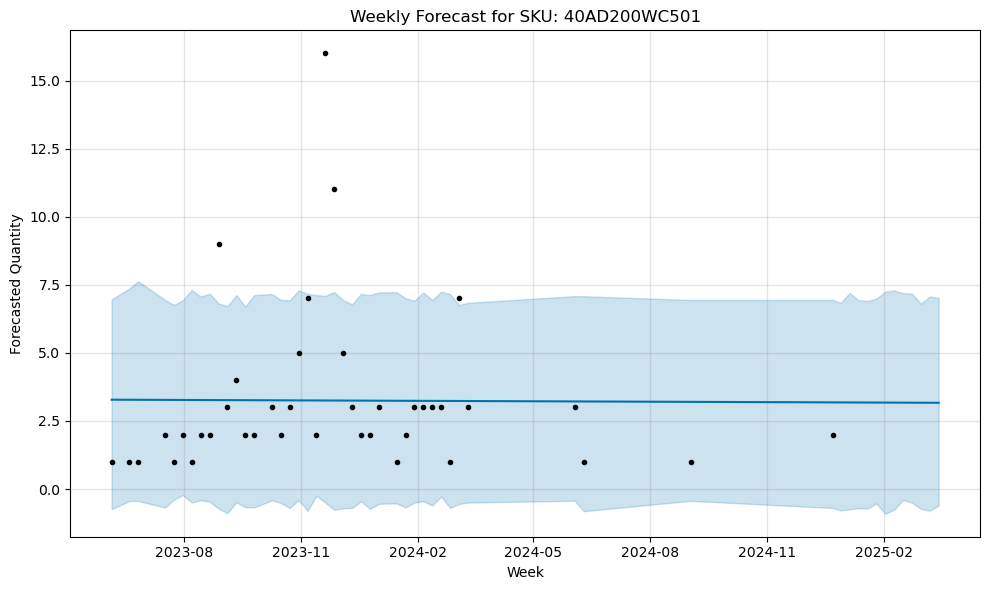

21:48:55 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD01AC01


21:48:55 - cmdstanpy - INFO - Chain [1] done processing


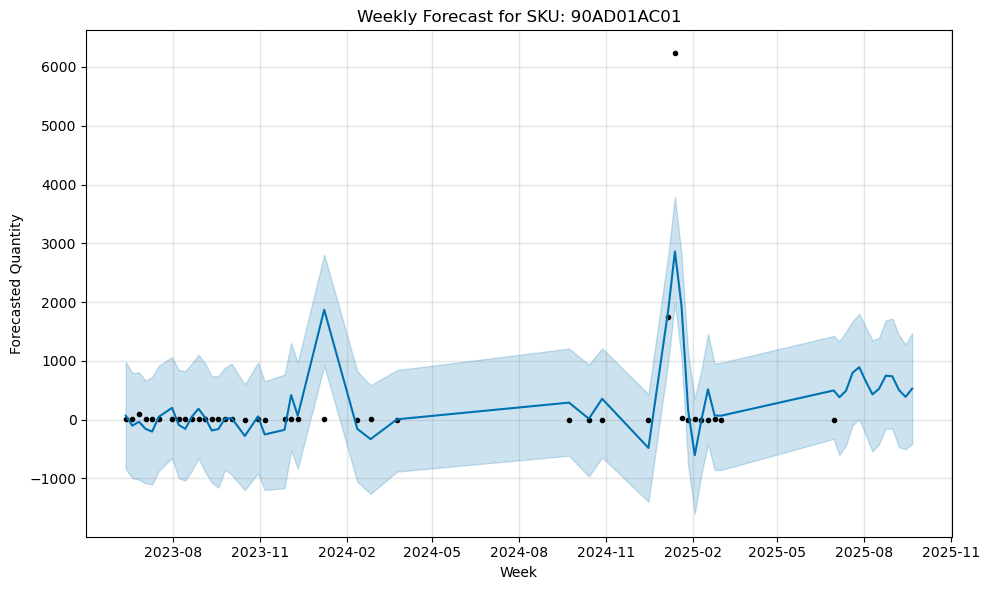

21:48:55 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD02AC01


21:48:56 - cmdstanpy - INFO - Chain [1] done processing


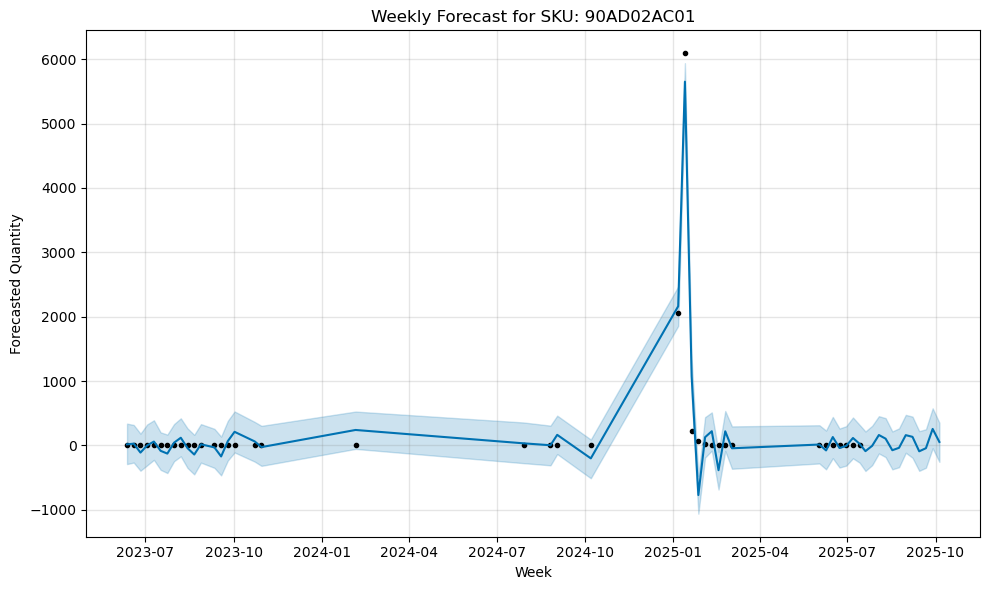

21:48:56 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD300PRF04


21:48:56 - cmdstanpy - INFO - Chain [1] done processing


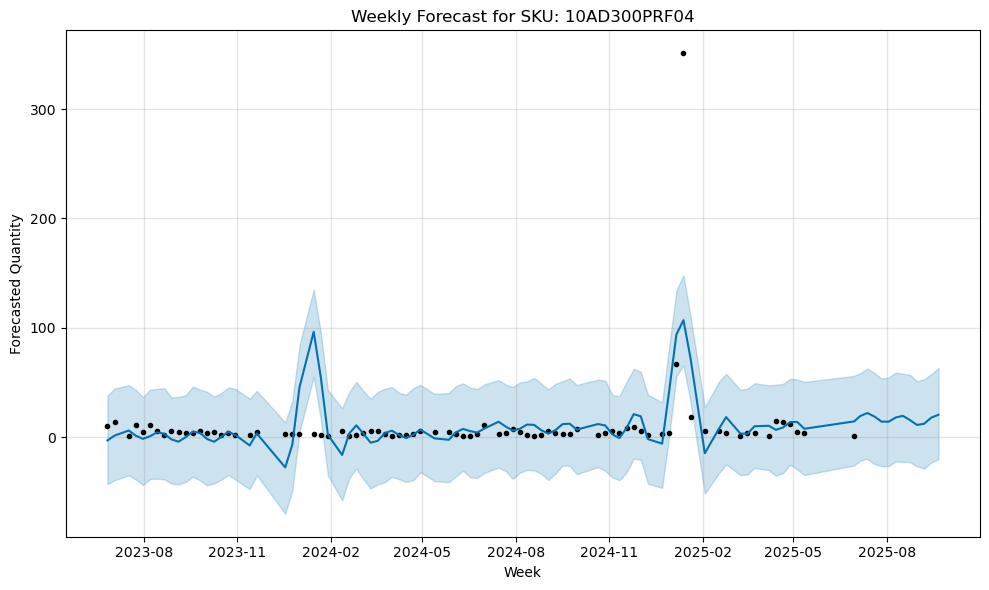

21:48:57 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD350CMPK1


21:48:57 - cmdstanpy - INFO - Chain [1] done processing


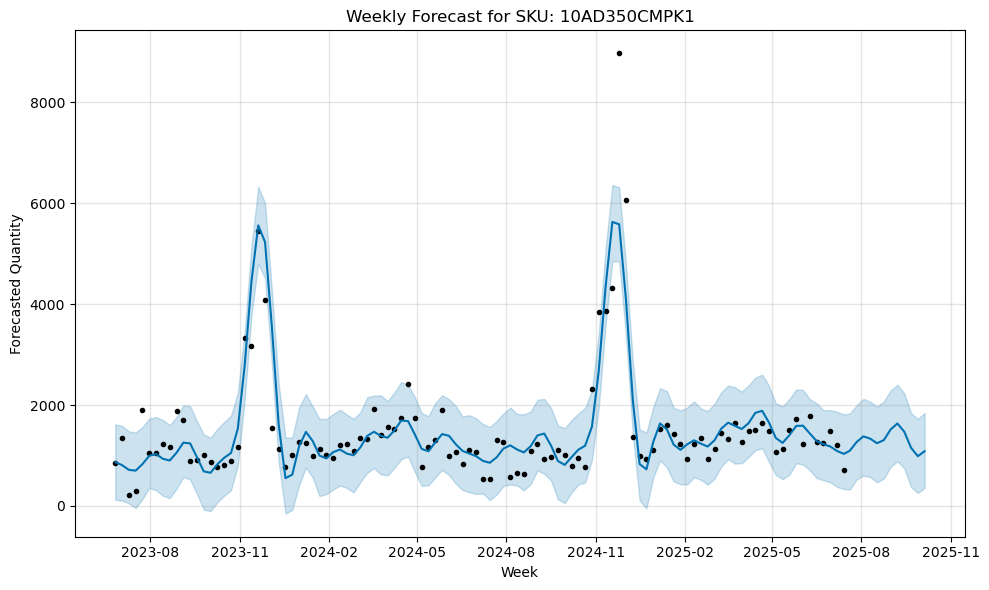

21:48:57 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD350GRF01


21:48:57 - cmdstanpy - INFO - Chain [1] done processing


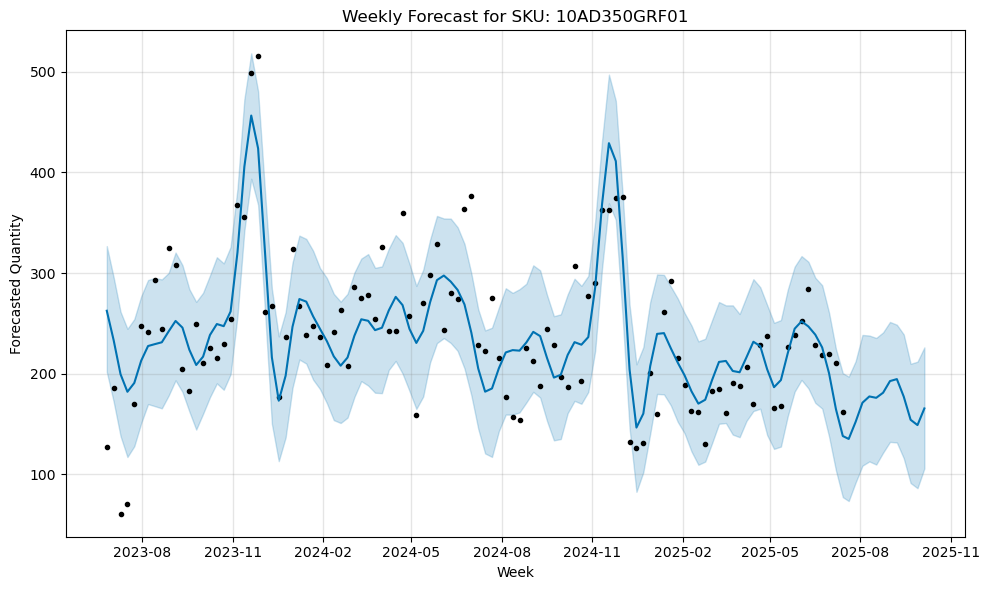

21:48:58 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD350HRF01


21:48:58 - cmdstanpy - INFO - Chain [1] done processing


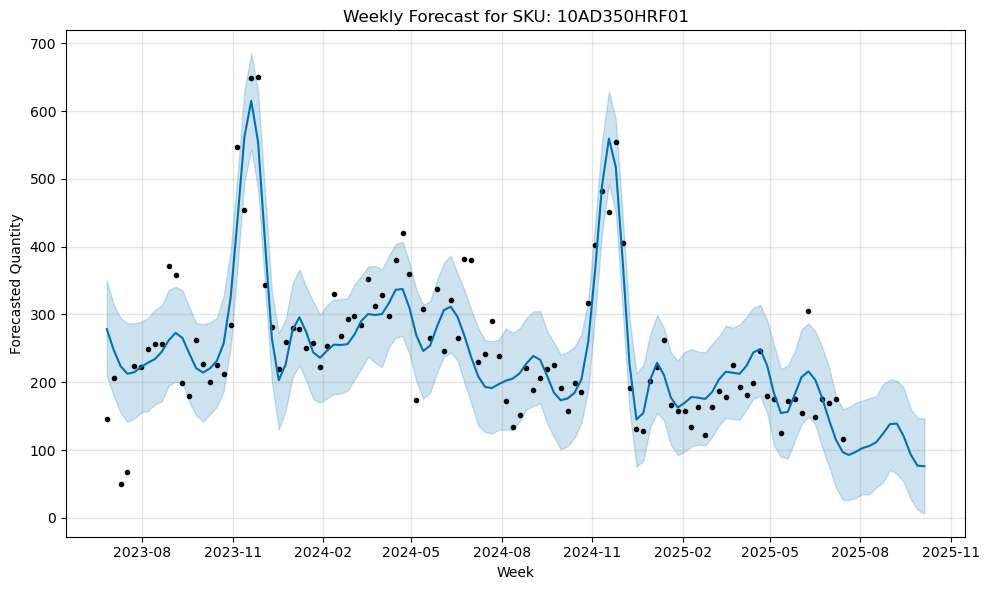

21:48:58 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD350PRF03


21:48:58 - cmdstanpy - INFO - Chain [1] done processing


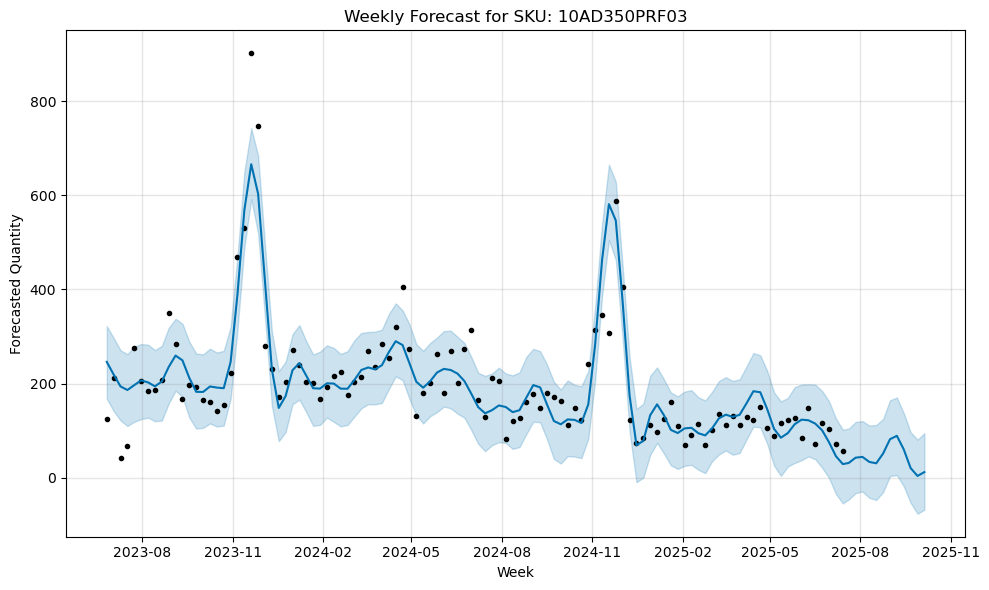

21:48:58 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD500PRF04C


21:48:59 - cmdstanpy - INFO - Chain [1] done processing


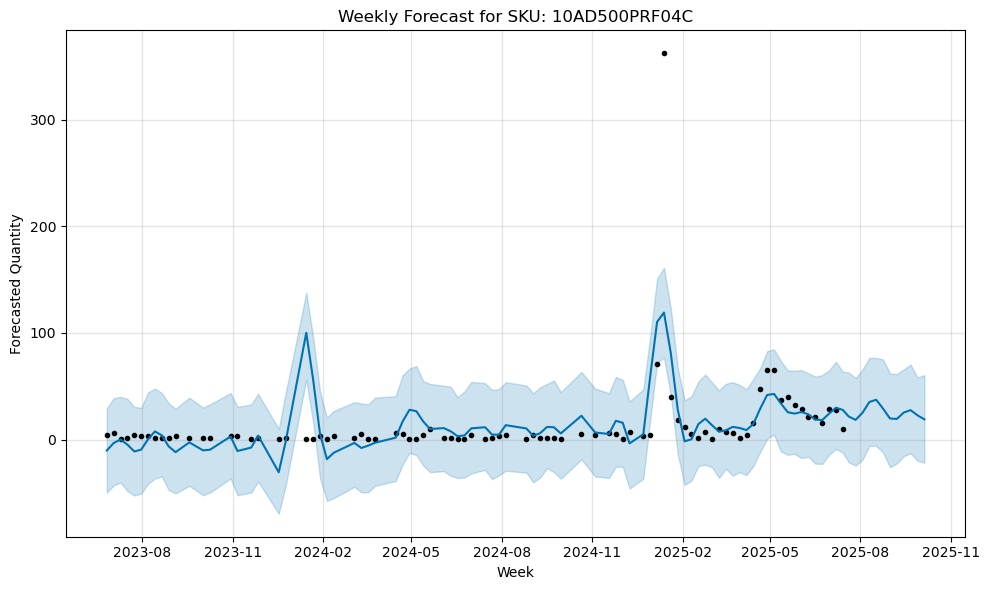

21:48:59 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD350SC01


21:48:59 - cmdstanpy - INFO - Chain [1] done processing


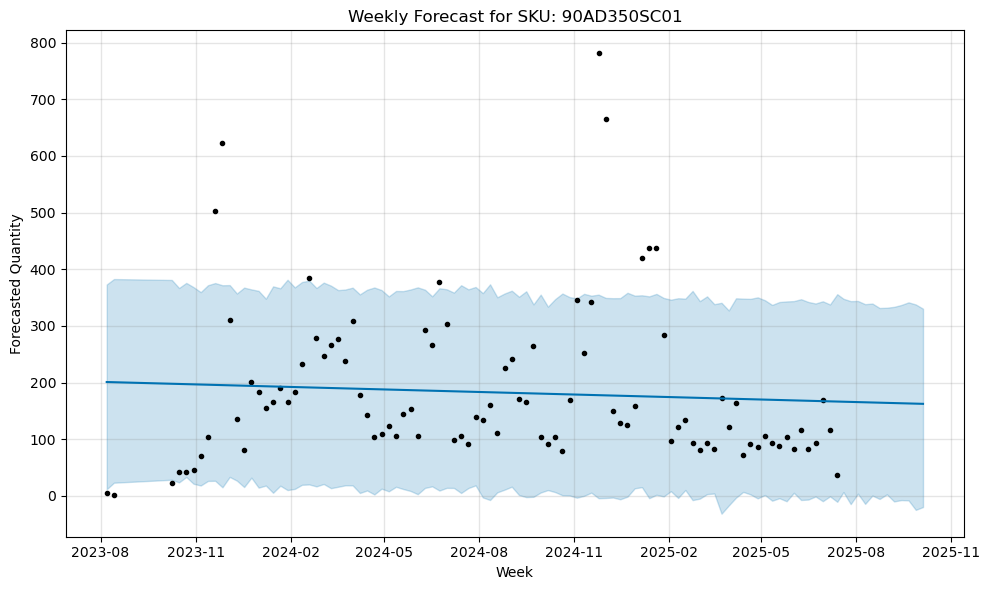

21:49:00 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD550SC01


21:49:00 - cmdstanpy - INFO - Chain [1] done processing


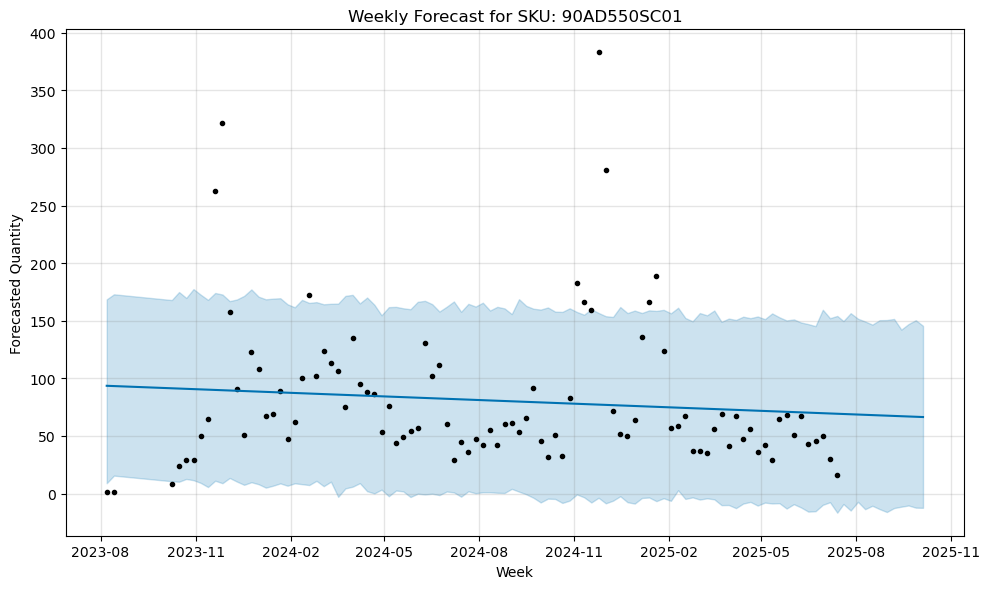

21:49:00 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD200CV01


21:49:00 - cmdstanpy - INFO - Chain [1] done processing


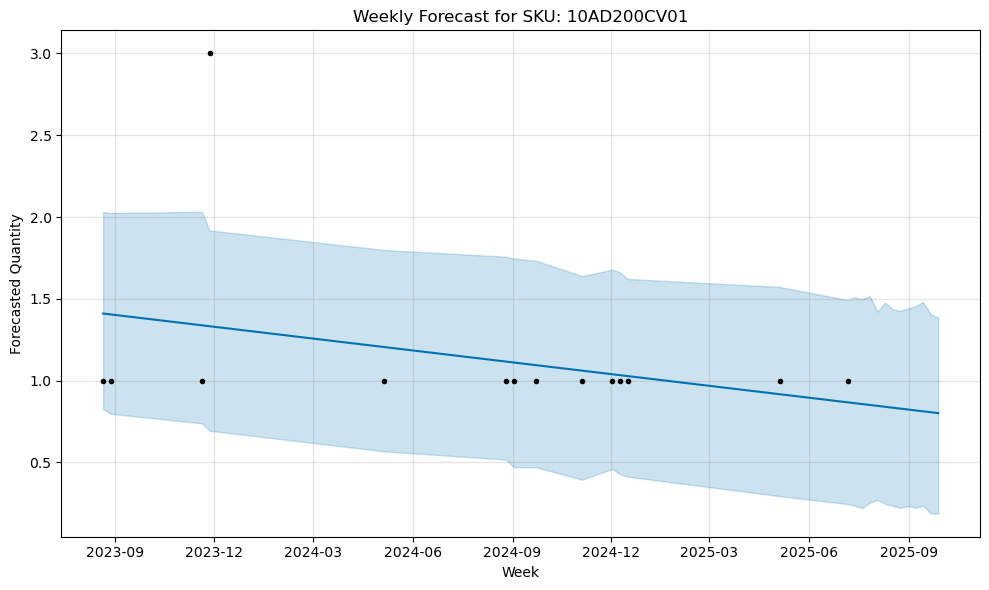

21:49:01 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD01CV01
  Skipped (not enough data: 3 weeks)
Processing forecast for SKU: 10AD300FC01


21:49:01 - cmdstanpy - INFO - Chain [1] done processing


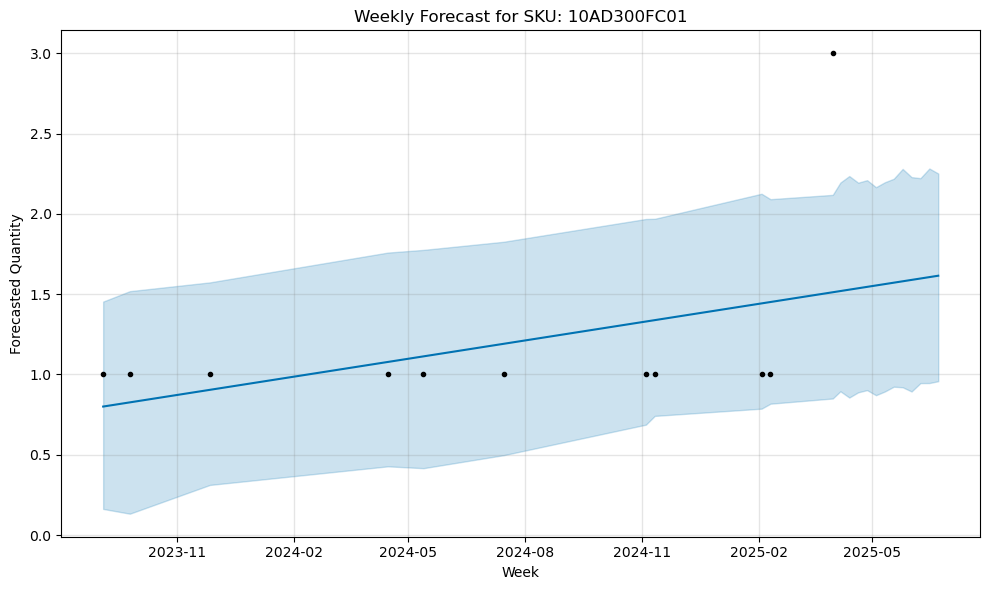

21:49:01 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B004


21:49:01 - cmdstanpy - INFO - Chain [1] done processing


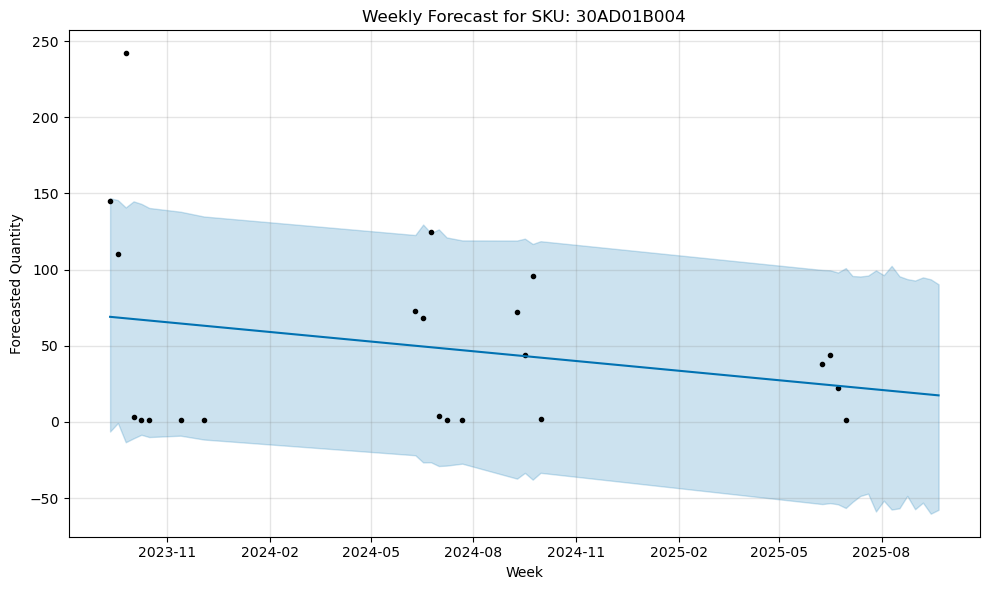

21:49:02 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD500CMPK1
  Skipped (not enough data: 5 weeks)
Processing forecast for SKU: 90AD200SC01


21:49:02 - cmdstanpy - INFO - Chain [1] done processing


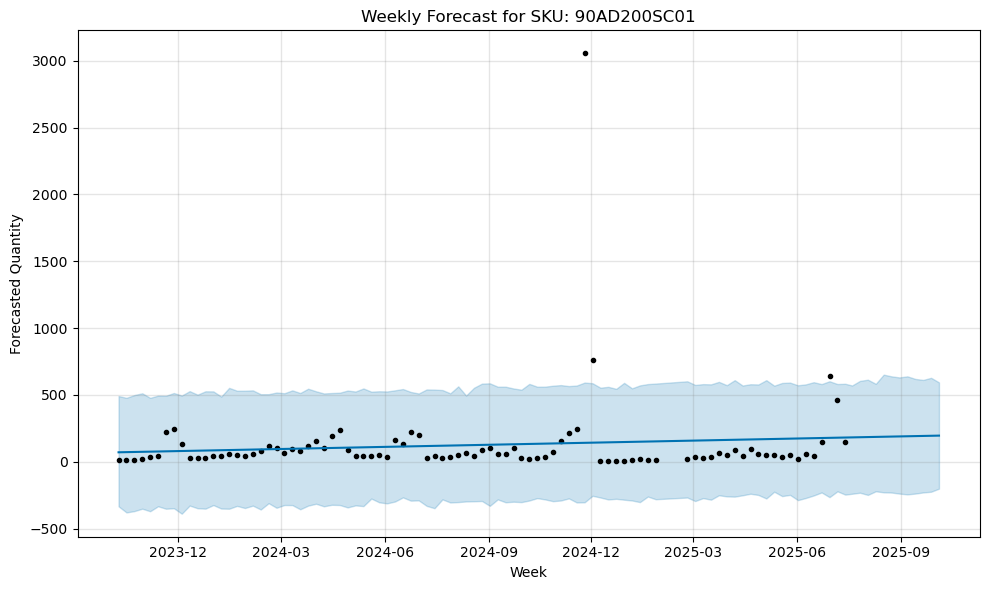

21:49:02 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B001


21:49:02 - cmdstanpy - INFO - Chain [1] done processing


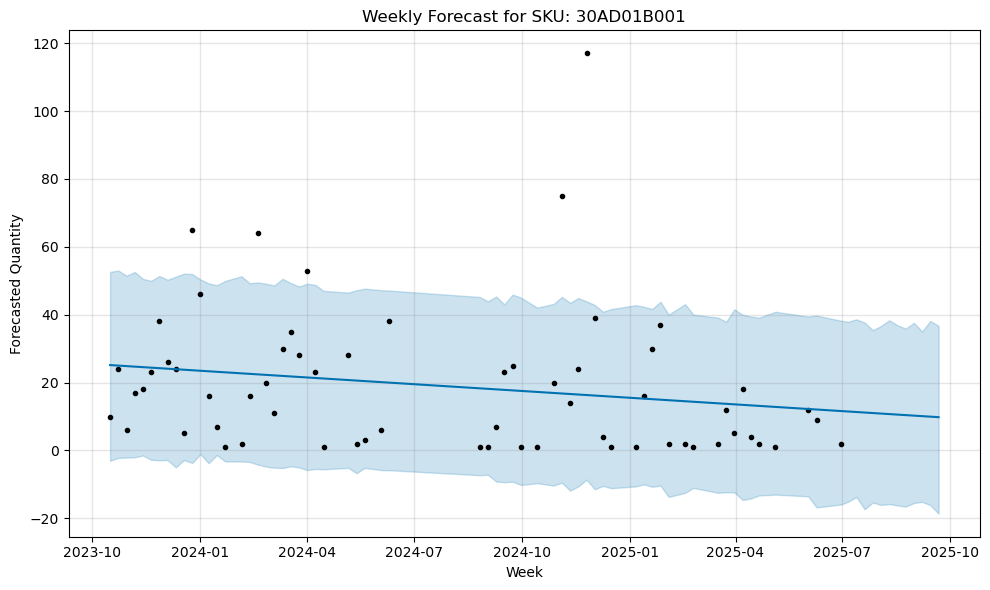

21:49:03 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B009


21:49:03 - cmdstanpy - INFO - Chain [1] done processing


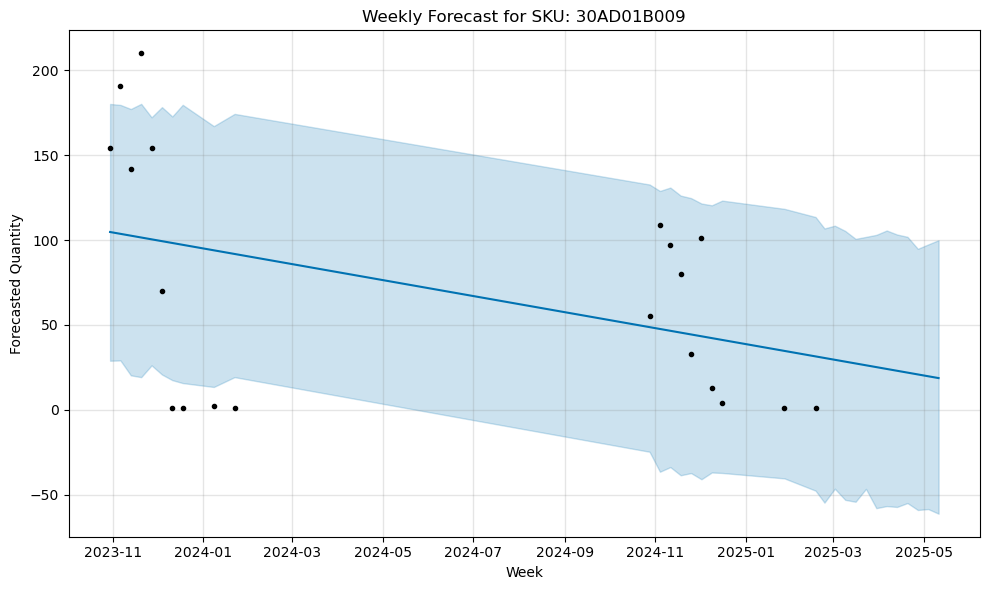

21:49:03 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B010


21:49:03 - cmdstanpy - INFO - Chain [1] done processing


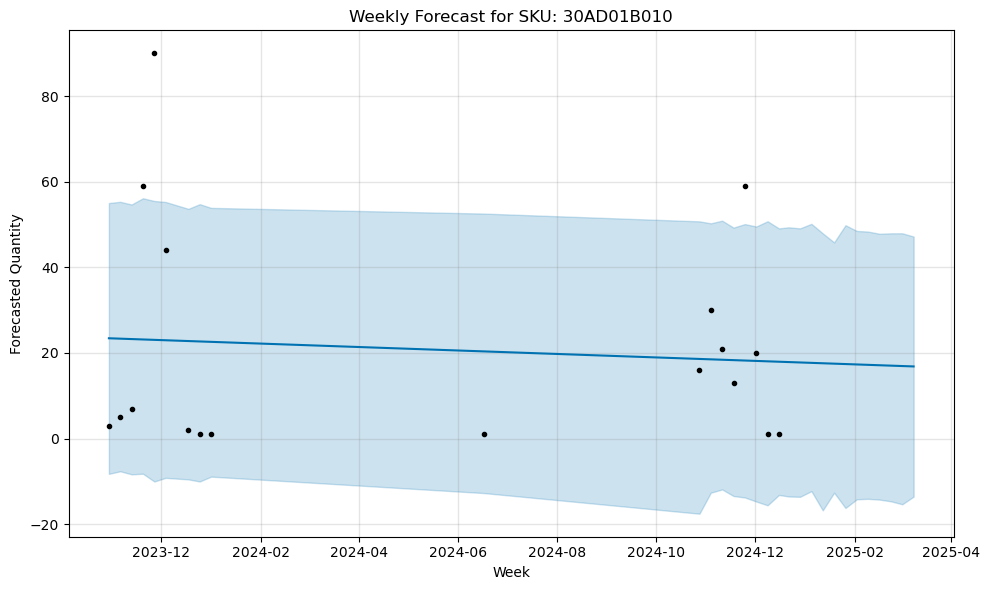

21:49:04 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD02CMPK2


21:49:04 - cmdstanpy - INFO - Chain [1] done processing


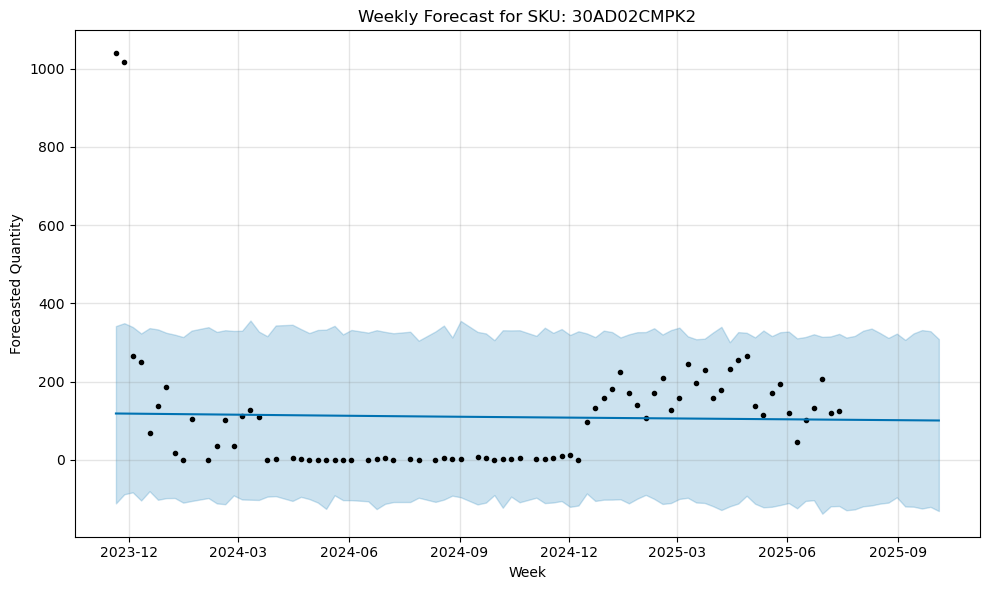

21:49:04 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD250PRF03


21:49:04 - cmdstanpy - INFO - Chain [1] done processing


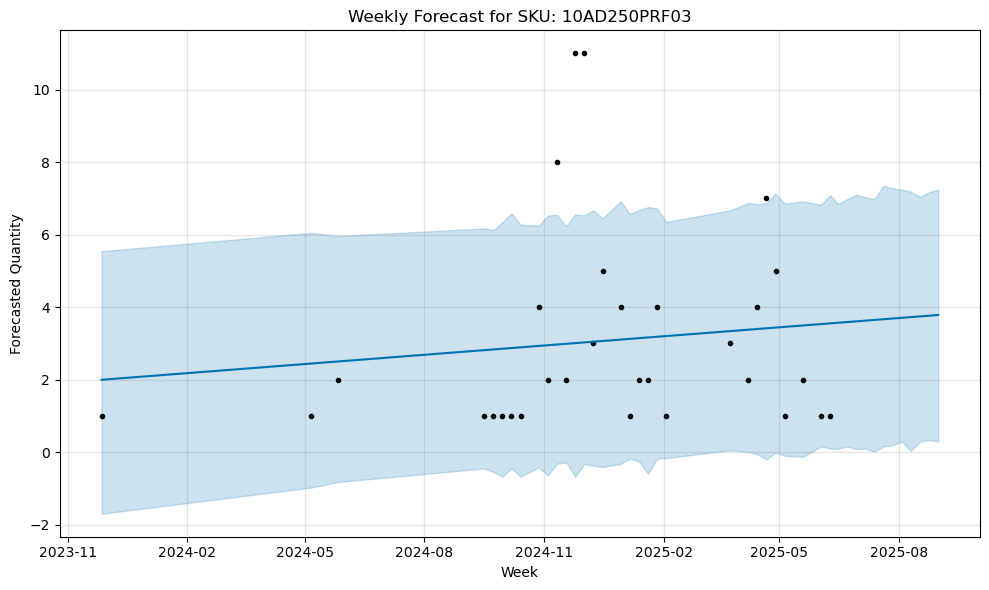

21:49:05 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD250HRF01


21:49:05 - cmdstanpy - INFO - Chain [1] done processing


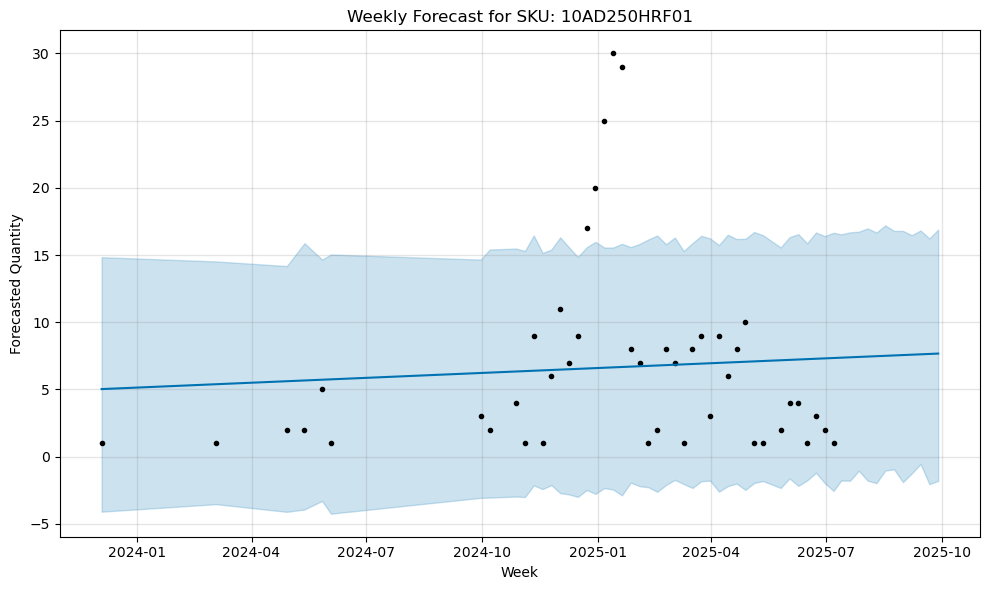

21:49:05 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD250CMPK1


21:49:05 - cmdstanpy - INFO - Chain [1] done processing


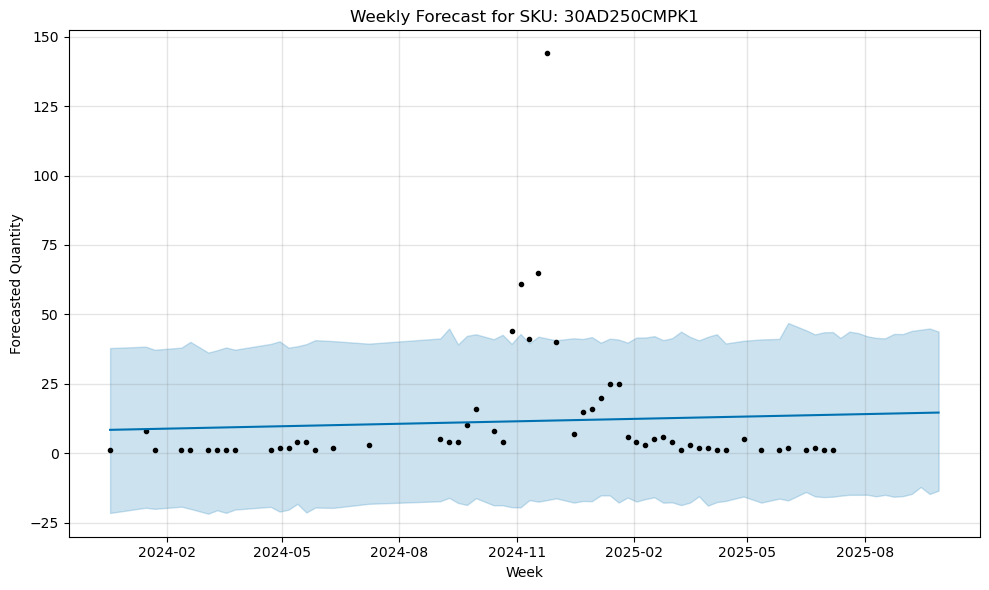

21:49:06 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD250AD01


21:49:06 - cmdstanpy - INFO - Chain [1] done processing


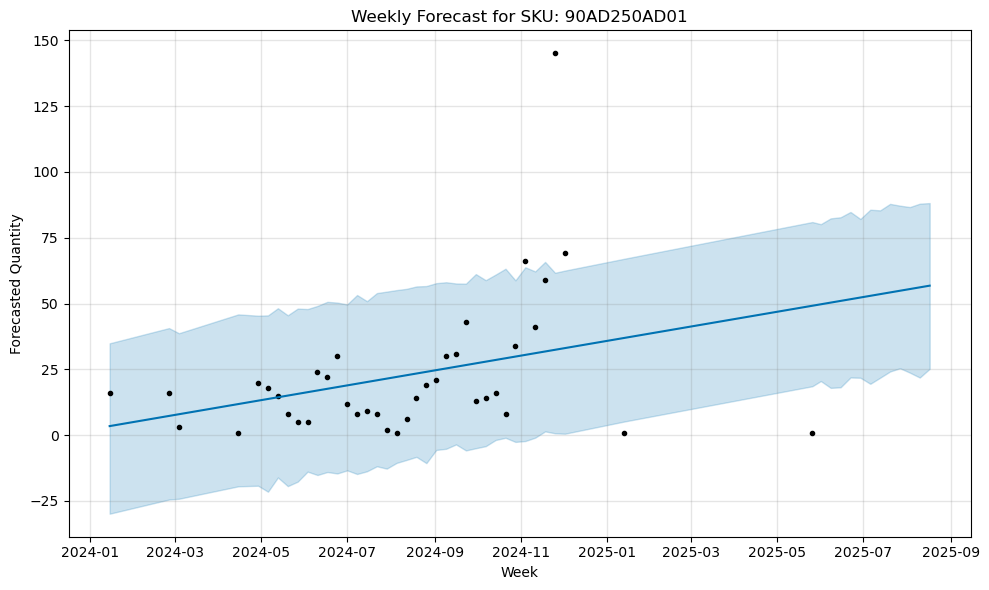

21:49:06 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B011


21:49:06 - cmdstanpy - INFO - Chain [1] done processing


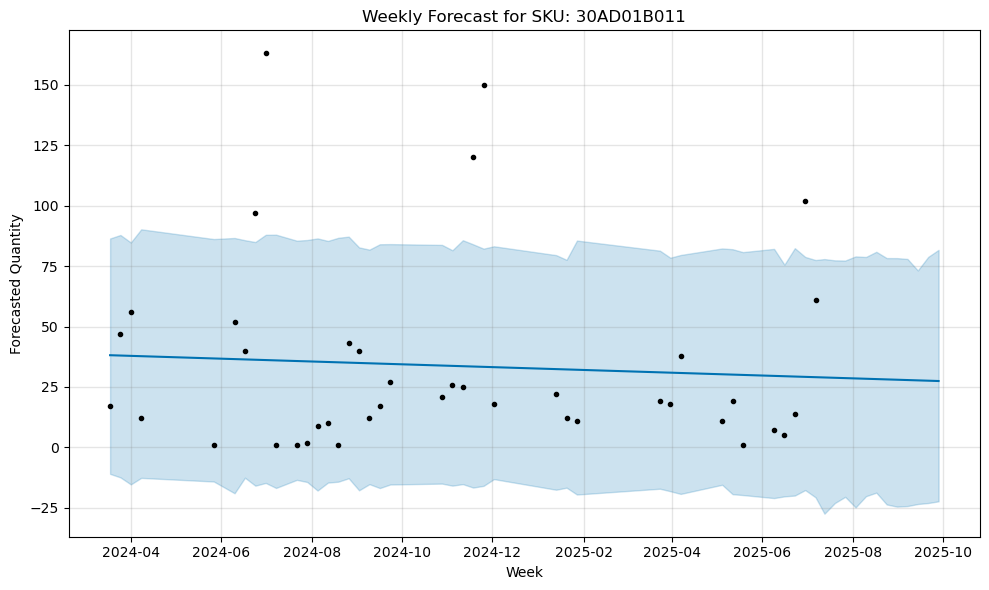

21:49:07 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B012


21:49:07 - cmdstanpy - INFO - Chain [1] done processing


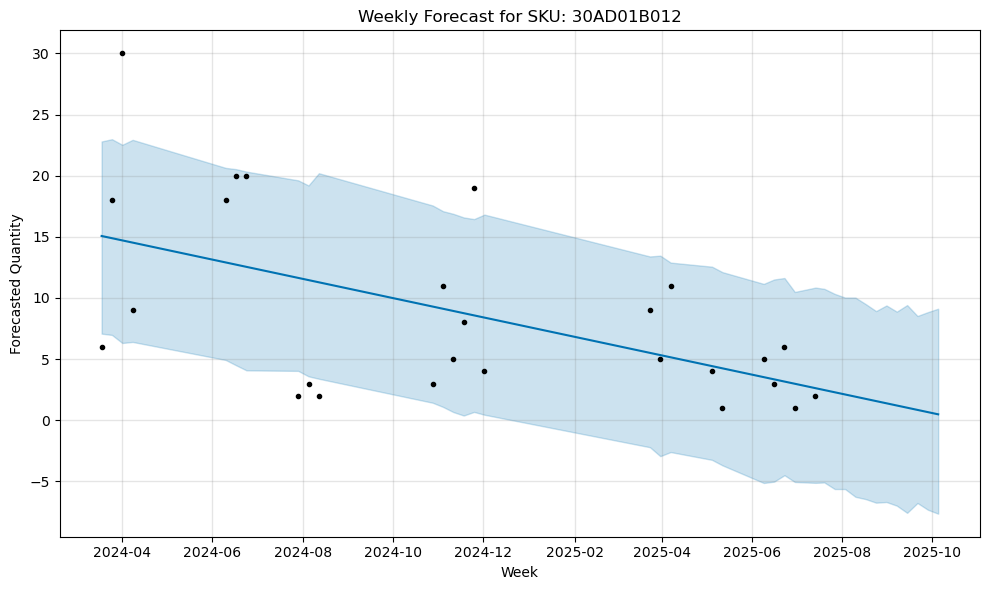

21:49:07 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD500CV01
  Skipped (not enough data: 9 weeks)
Processing forecast for SKU: 30AD01B013


21:49:08 - cmdstanpy - INFO - Chain [1] done processing


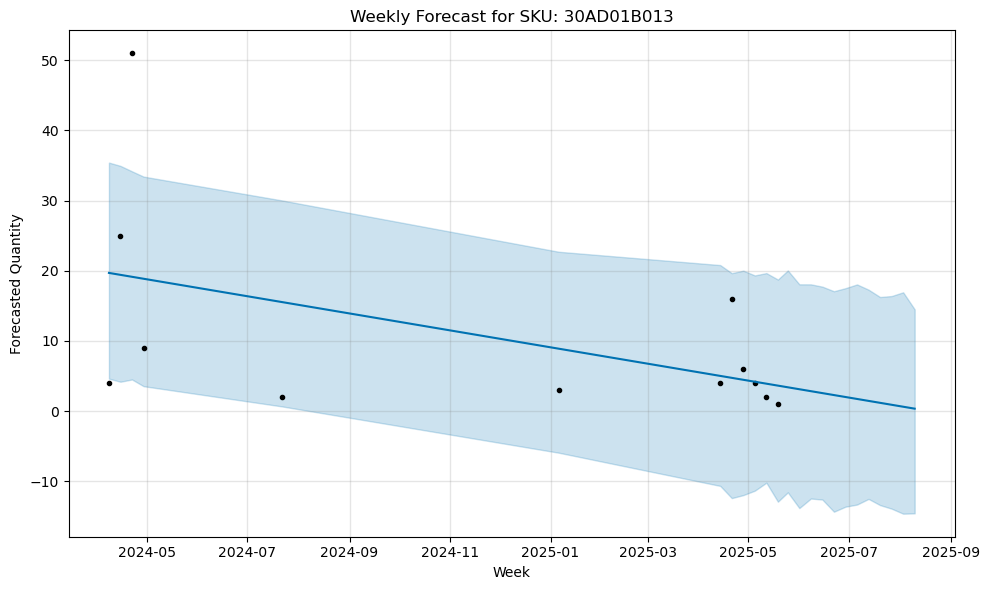

21:49:08 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B014


21:49:08 - cmdstanpy - INFO - Chain [1] done processing


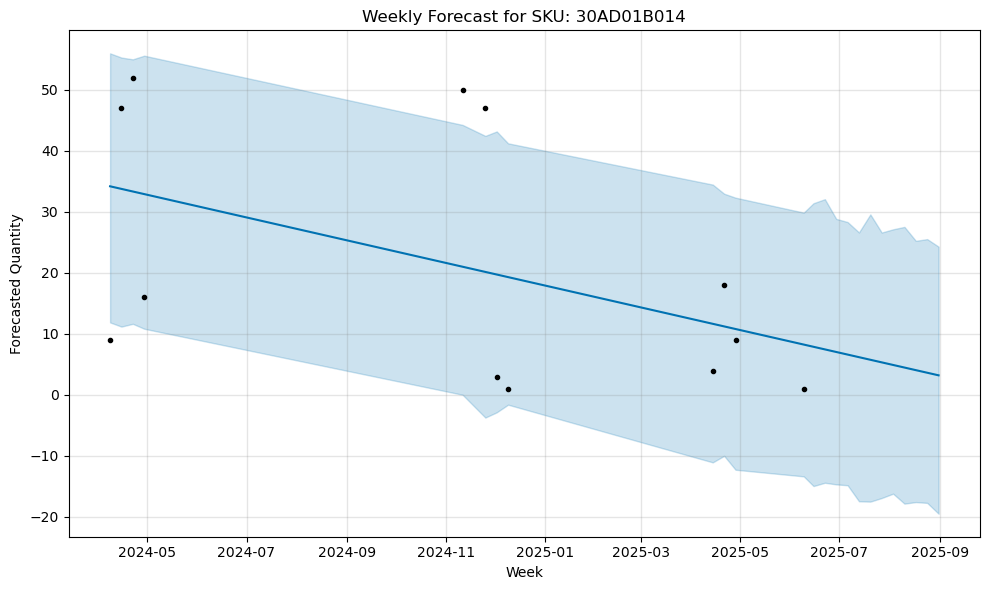

21:49:08 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B015


21:49:09 - cmdstanpy - INFO - Chain [1] done processing


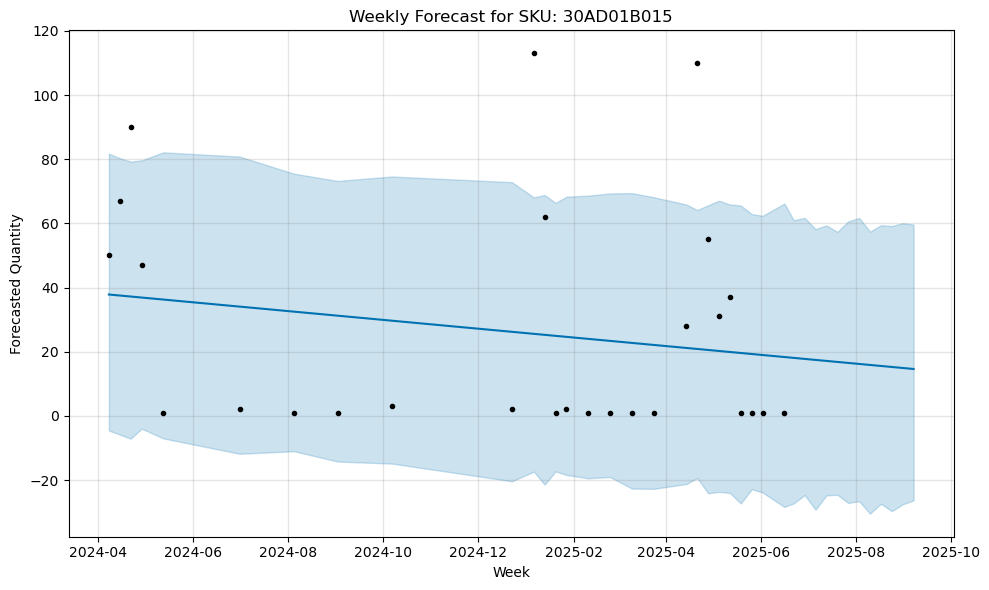

21:49:09 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B016


21:49:09 - cmdstanpy - INFO - Chain [1] done processing


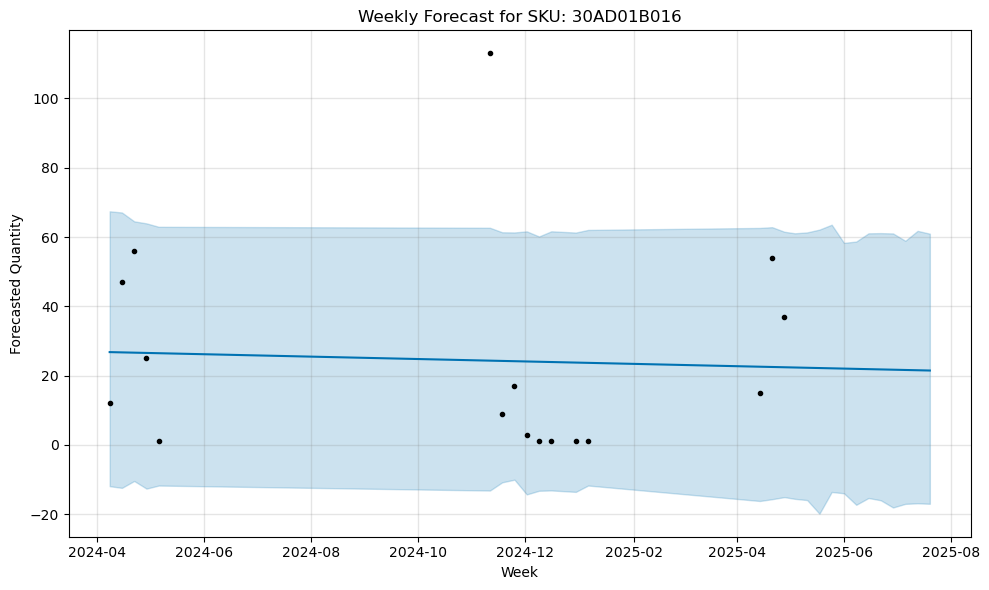

21:49:09 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD250GRF01


21:49:09 - cmdstanpy - INFO - Chain [1] done processing


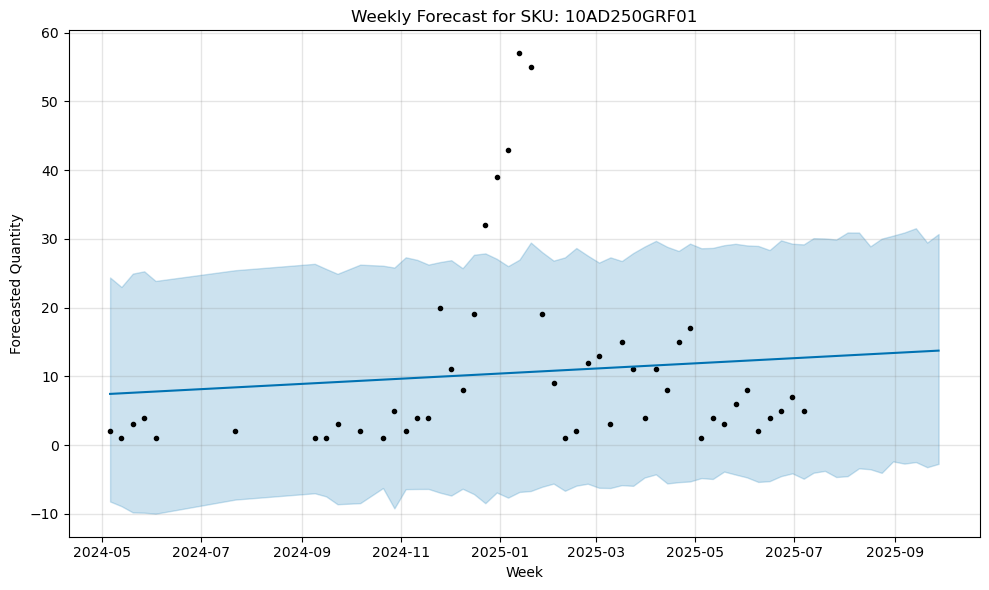

21:49:10 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B020
  Skipped (not enough data: 8 weeks)
Processing forecast for SKU: 30AD01B021
  Skipped (not enough data: 5 weeks)
Processing forecast for SKU: 30AD01B017
  Skipped (not enough data: 2 weeks)
Processing forecast for SKU: 30AD01B018
  Skipped (not enough data: 8 weeks)
Processing forecast for SKU: 30AD01B019
  Skipped (not enough data: 7 weeks)
Processing forecast for SKU: 30AD01B022
  Skipped (not enough data: 3 weeks)
Processing forecast for SKU: 30AD01B023
  Skipped (not enough data: 2 weeks)
Processing forecast for SKU: 30AD01B024
  Skipped (not enough data: 7 weeks)
Processing forecast for SKU: 30AD01B025
  Skipped (not enough data: 8 weeks)
Processing forecast for SKU: 30AD500CMPK2


21:49:10 - cmdstanpy - INFO - Chain [1] done processing


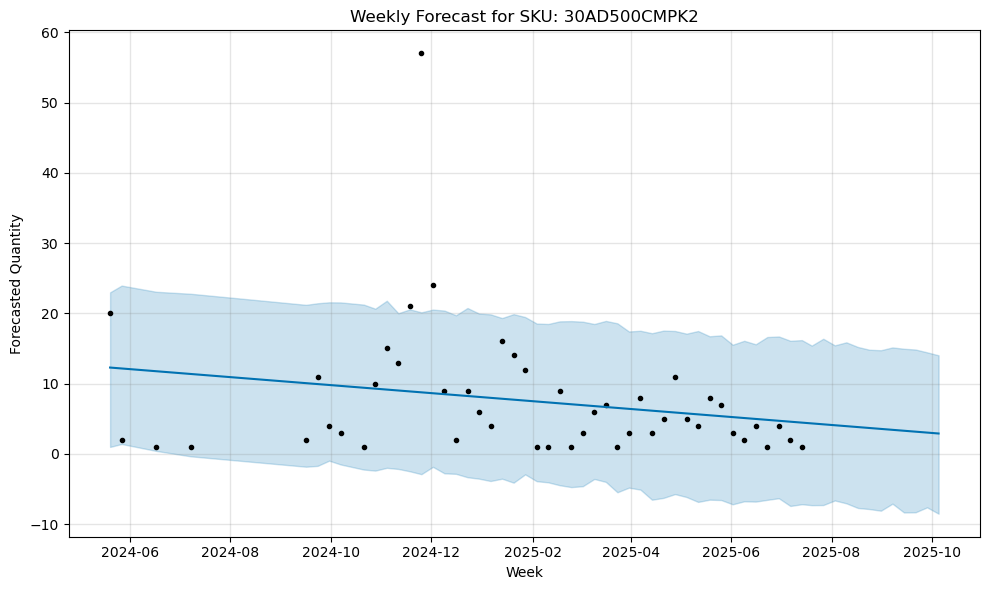

21:49:10 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B026


21:49:10 - cmdstanpy - INFO - Chain [1] done processing


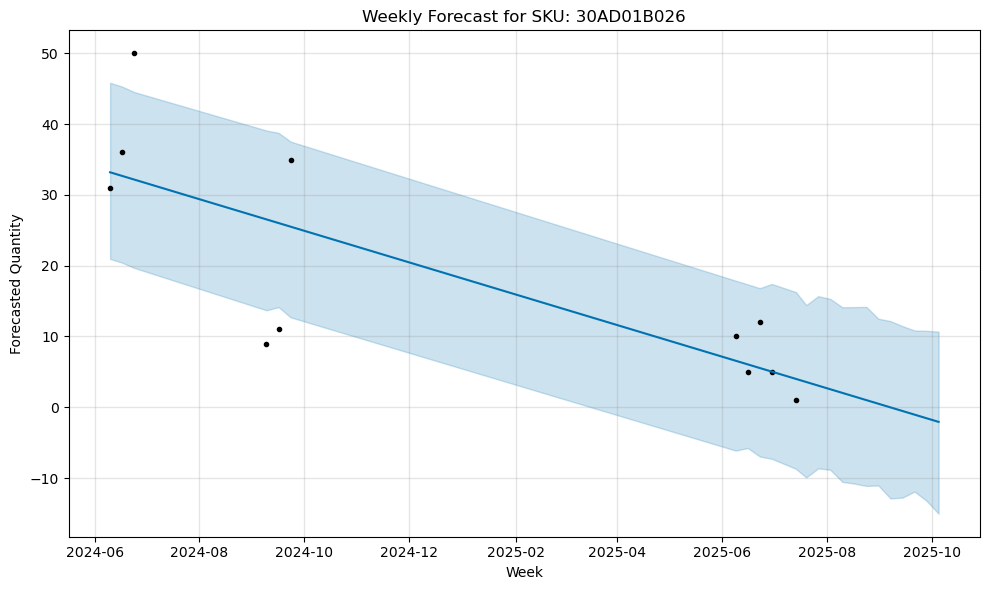

21:49:11 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B027


21:49:11 - cmdstanpy - INFO - Chain [1] done processing


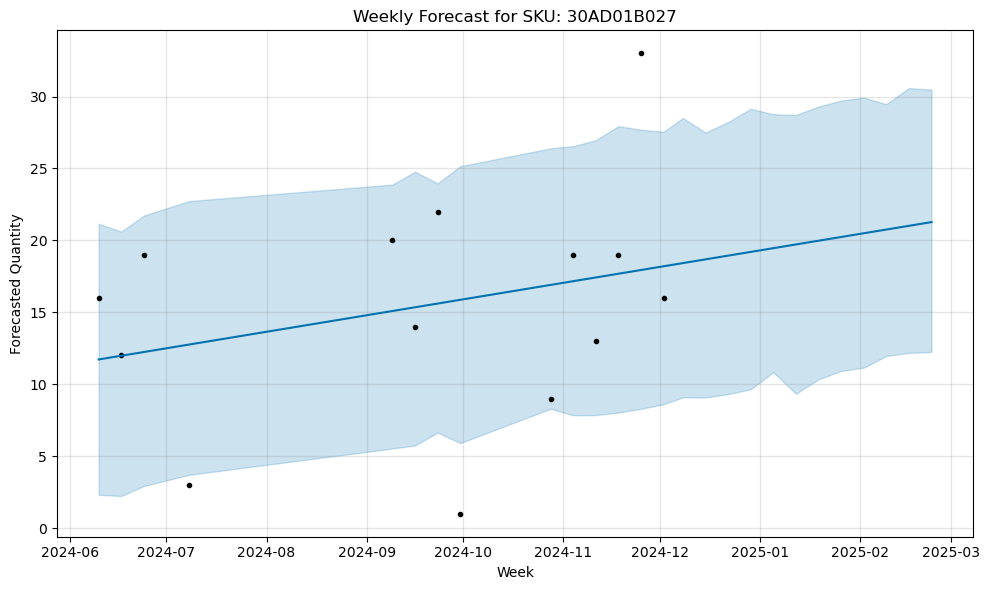

21:49:11 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B029
  Skipped (not enough data: 2 weeks)
Processing forecast for SKU: 40AD200MN01
  Skipped (not enough data: 3 weeks)
Processing forecast for SKU: 30AD350CMPK2


21:49:11 - cmdstanpy - INFO - Chain [1] done processing


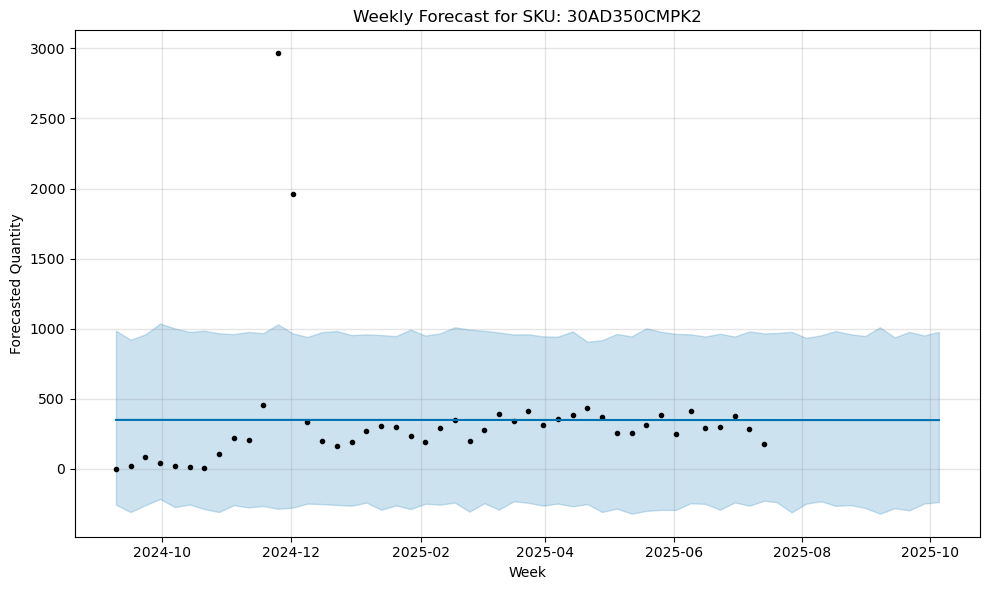

21:49:12 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD200CMPK2


21:49:12 - cmdstanpy - INFO - Chain [1] done processing


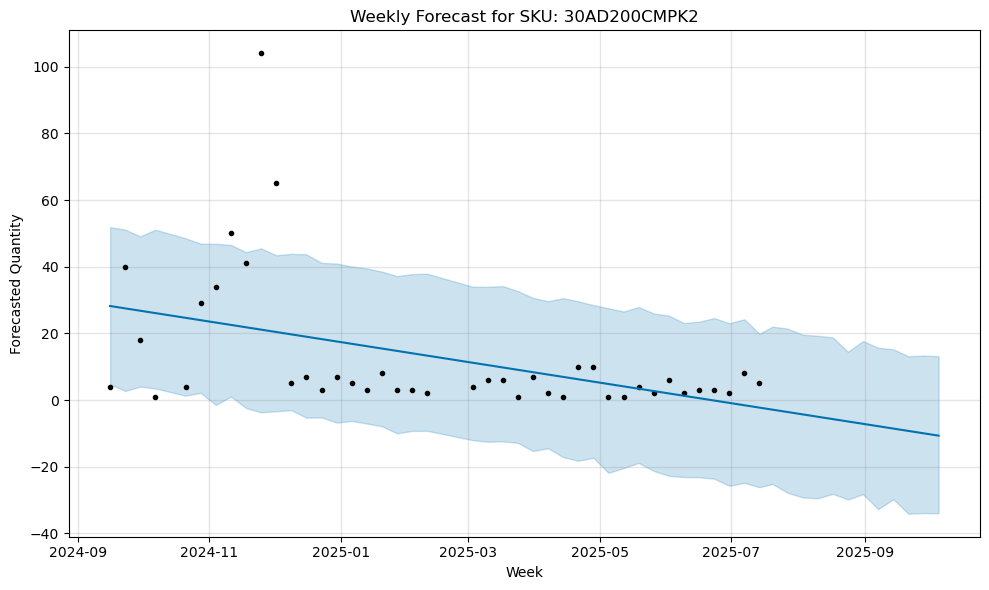

21:49:12 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B028
  Skipped (not enough data: 7 weeks)
Processing forecast for SKU: 30AD01TF02
  Skipped (not enough data: 1 weeks)
Processing forecast for SKU: 30AD250CMPK2
  Skipped (not enough data: 9 weeks)
Processing forecast for SKU: 30AD01B030


21:49:12 - cmdstanpy - INFO - Chain [1] done processing


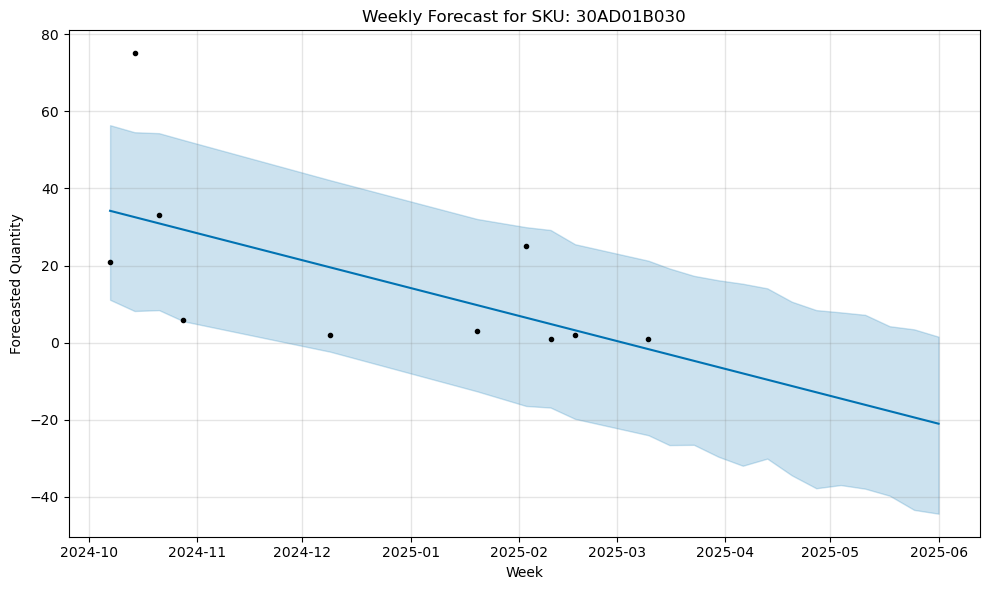

21:49:13 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B031
  Skipped (not enough data: 8 weeks)
Processing forecast for SKU: 30AD01B036
  Skipped (not enough data: 5 weeks)
Processing forecast for SKU: 40AD200UP01


21:49:13 - cmdstanpy - INFO - Chain [1] done processing


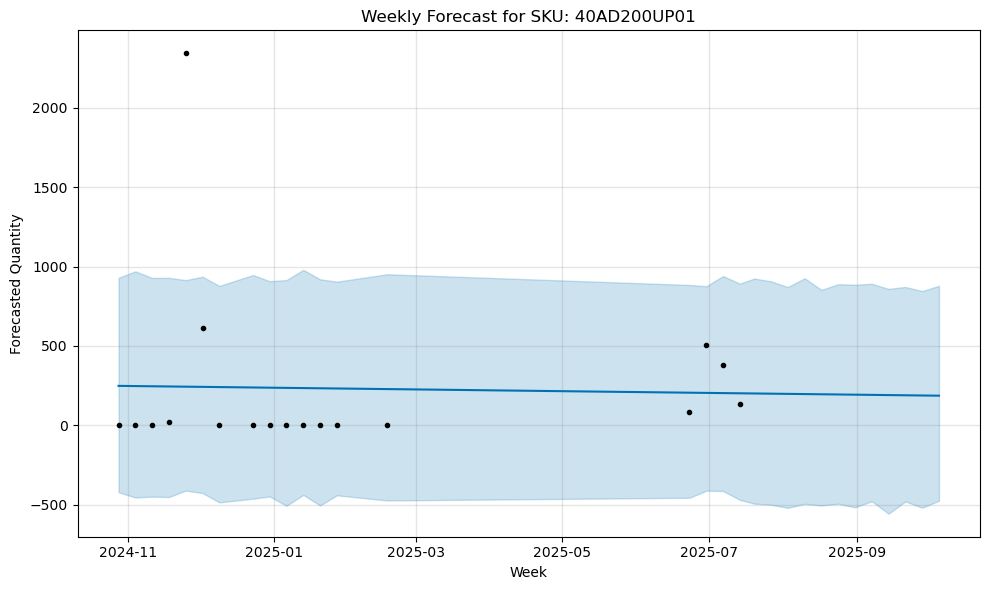

21:49:13 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B032


21:49:13 - cmdstanpy - INFO - Chain [1] done processing


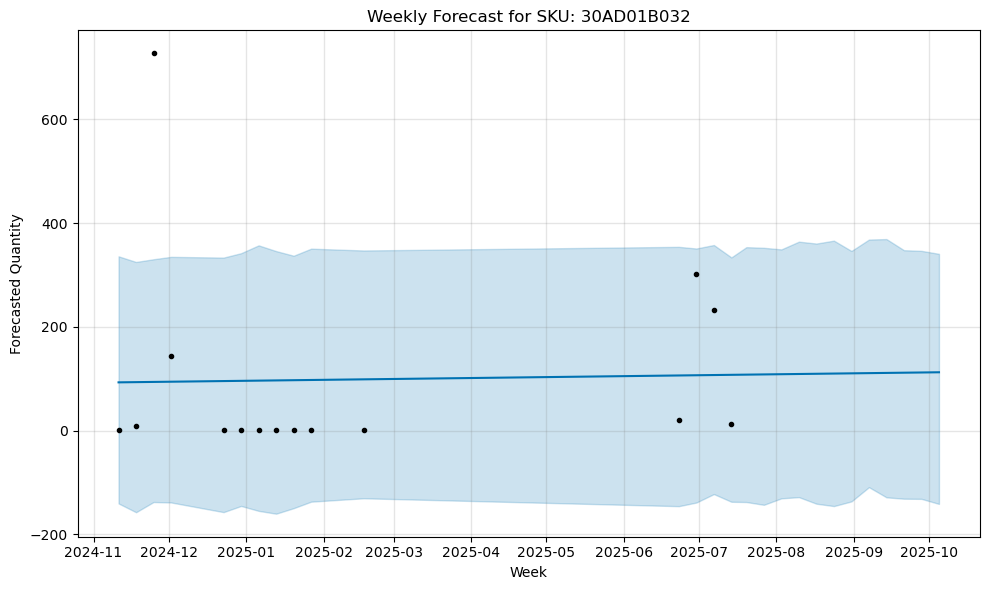

21:49:14 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD550CMPK2


21:49:14 - cmdstanpy - INFO - Chain [1] done processing


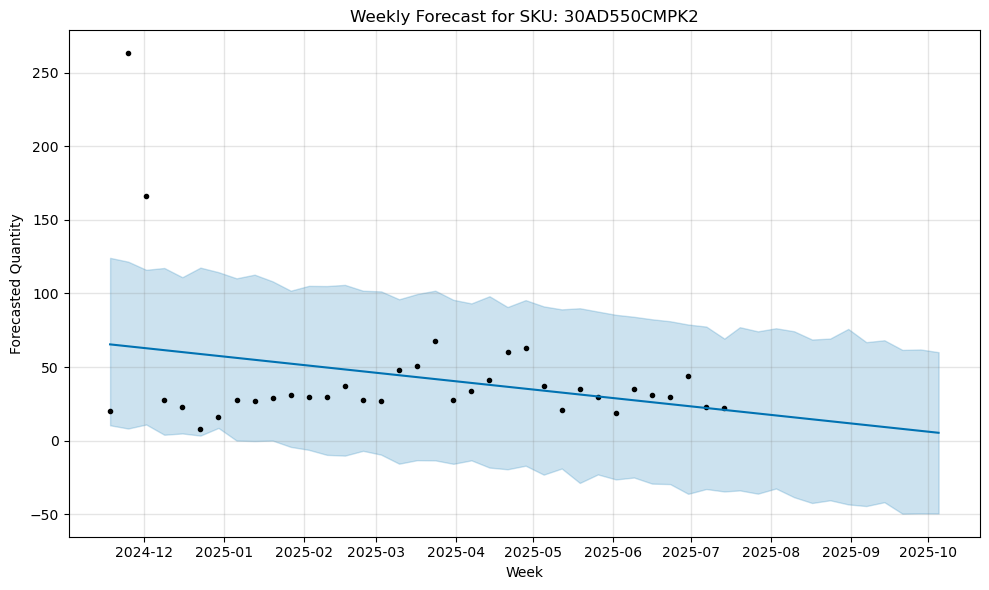

21:49:14 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B035
  Skipped (not enough data: 6 weeks)
Processing forecast for SKU: 30AD01B037
  Skipped (not enough data: 1 weeks)
Processing forecast for SKU: 30AD01B038
  Skipped (not enough data: 2 weeks)
Processing forecast for SKU: 30AD01B034
  Skipped (not enough data: 1 weeks)
Processing forecast for SKU: 90AD400AD01-B


21:49:14 - cmdstanpy - INFO - Chain [1] done processing


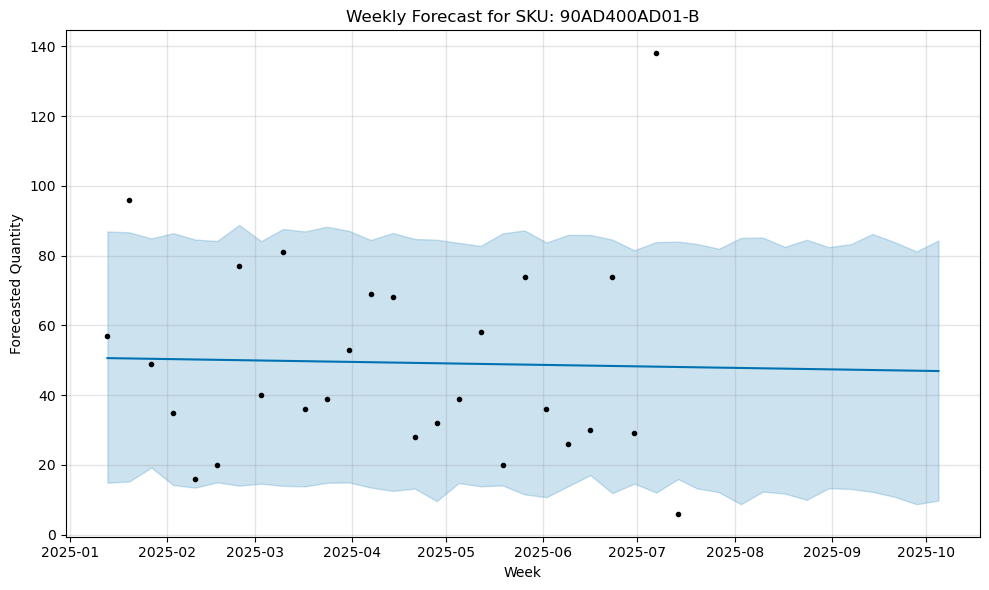

21:49:15 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 90AD400AD01-W


21:49:15 - cmdstanpy - INFO - Chain [1] done processing


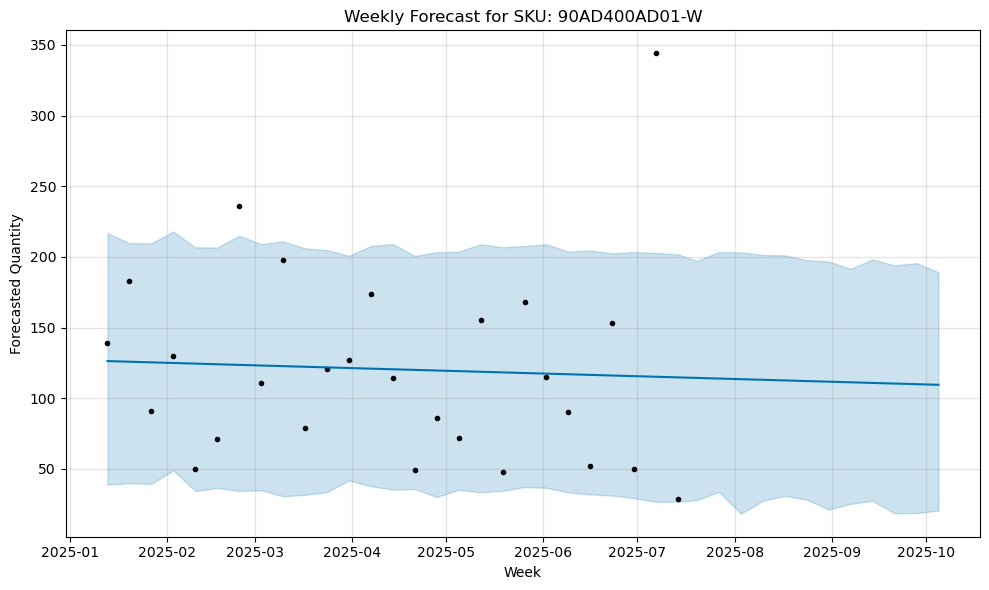

21:49:15 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 10AD300PRF01C


21:49:15 - cmdstanpy - INFO - Chain [1] done processing


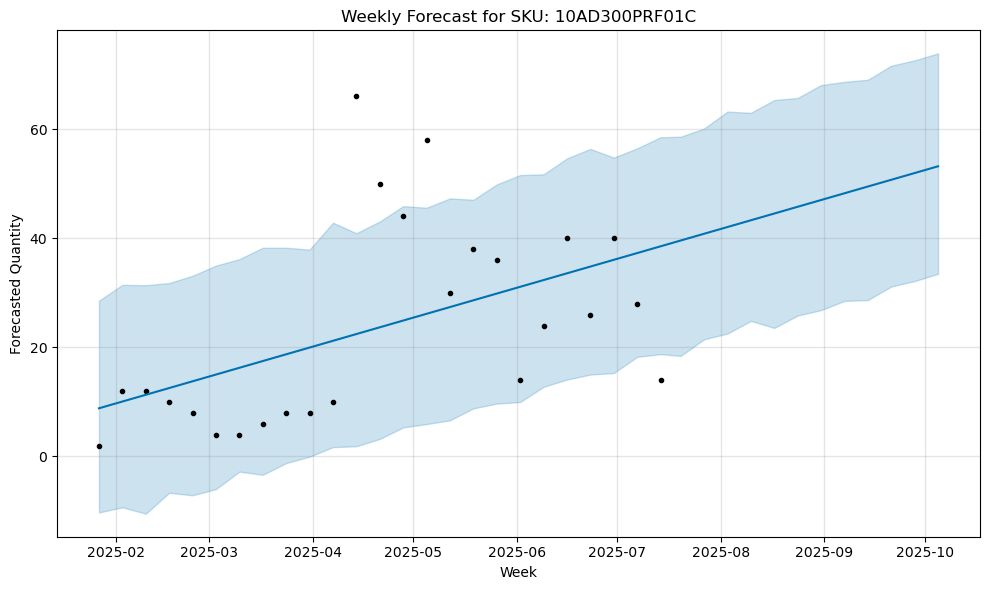

21:49:16 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B039
  Skipped (not enough data: 1 weeks)
Processing forecast for SKU: 30AD300PRF02C


21:49:16 - cmdstanpy - INFO - Chain [1] done processing


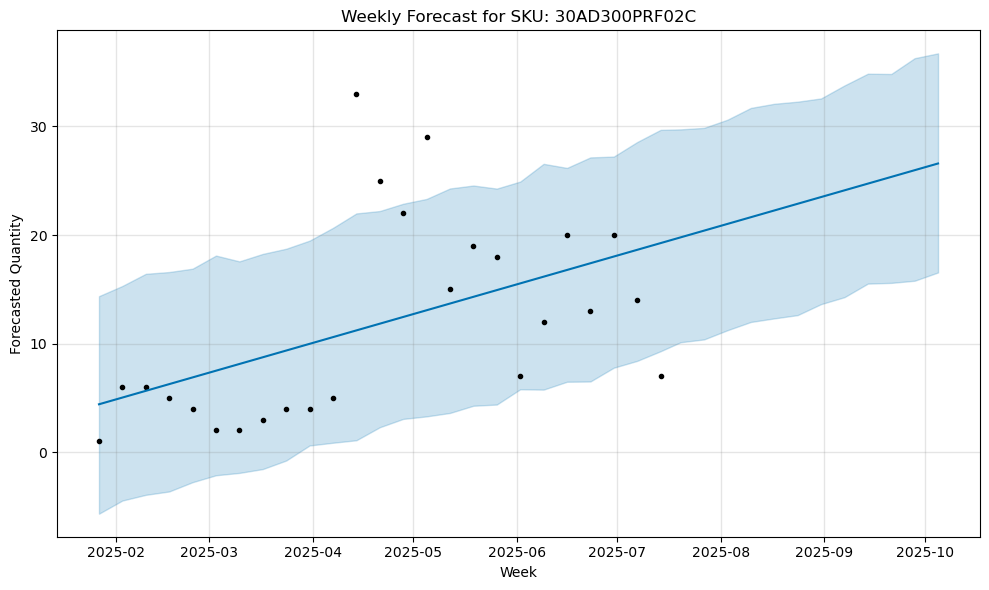

21:49:16 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 40AD01MN01
  Skipped (not enough data: 1 weeks)
Processing forecast for SKU: 10AD250CMPK1


21:49:16 - cmdstanpy - INFO - Chain [1] done processing


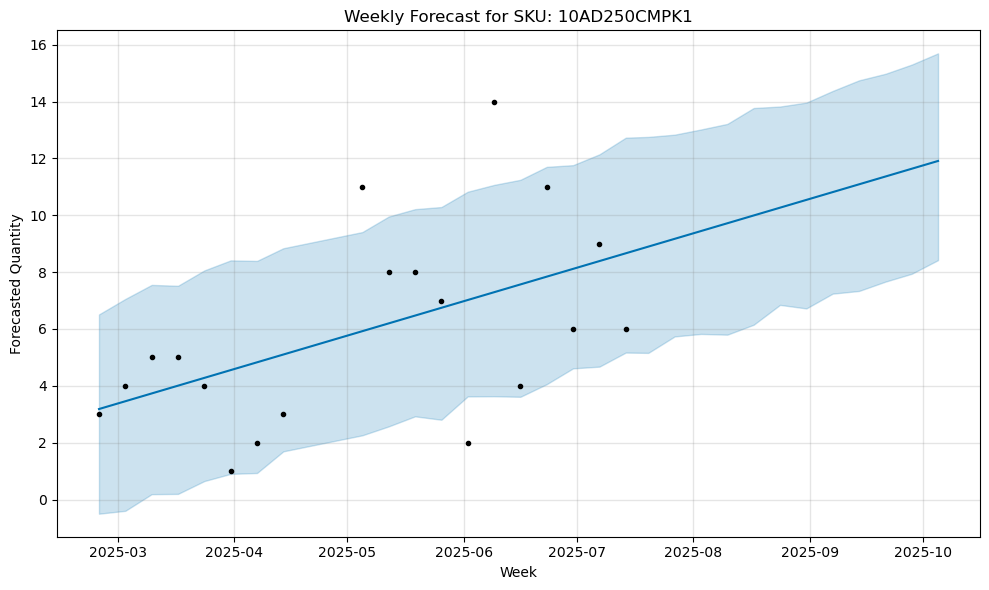

21:49:16 - cmdstanpy - INFO - Chain [1] start processing


Processing forecast for SKU: 30AD01B043
  Skipped (not enough data: 5 weeks)
Processing forecast for SKU: 30AD01B044
  Skipped (not enough data: 3 weeks)
Processing forecast for SKU: 30AD01B045
  Skipped (not enough data: 6 weeks)
Processing forecast for SKU: 30AD01B049
  Skipped (not enough data: 3 weeks)
Processing forecast for SKU: 30AD01SUR01


21:49:17 - cmdstanpy - INFO - Chain [1] done processing


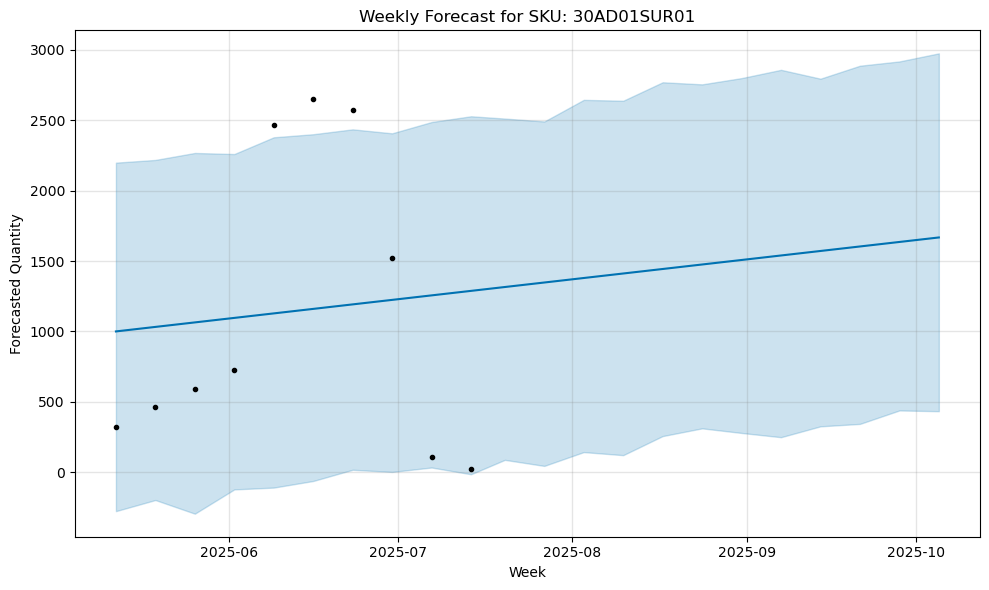

Processing forecast for SKU: 30AD01B046
  Skipped (not enough data: 4 weeks)
Processing forecast for SKU: 30AD01B047
  Skipped (not enough data: 3 weeks)
Processing forecast for SKU: 30AD01B048
  Skipped (not enough data: 3 weeks)
Processing forecast for SKU: 30AD01B033
  Skipped (not enough data: 4 weeks)


In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# STEP 1: Convert date to weekly
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# STEP 2: Group by Week and SKU (Aggregates data to compute quantity per SKU per week.)
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuanity'].sum().reset_index()

# STEP 3: Loop over each SKU
forecast_results = {}

for sku in weekly_by_sku['SKU'].unique():
    print(f"Processing forecast for SKU: {sku}")

    # Filter data for this SKU
    df_sku = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuanity']].copy()
    df_sku.columns = ['ds', 'y']  # Prophet requires these column names
    
    # Skip if there are too few data points
    if len(df_sku) < 10:
        print(f"  Skipped (not enough data: {len(df_sku)} weeks)")
        continue

    # Fit Prophet model
    model = Prophet()
    model.fit(df_sku)

    # Forecast 12 weeks ahead
    future = model.make_future_dataframe(periods=12, freq='W')
    forecast = model.predict(future)

    # Store result
    forecast['SKU'] = sku
    forecast_results[sku] = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

    # OPTIONAL: Plot for each SKU
    model.plot(forecast)
    plt.title(f"Weekly Forecast for SKU: {sku}")
    plt.xlabel("Week")
    plt.ylabel("Forecasted Quantity")
    plt.tight_layout()
    plt.show()


In [152]:
with pd.ExcelWriter("SKU_Forecasts.xlsx") as writer:
    for sku, df_forecast in forecast_results.items():
        df_forecast.to_excel(writer, sheet_name=sku[:31], index=False)  # Excel sheet name max = 31 chars


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 755567 entries, 0 to 858257
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ProductFamily     755567 non-null  object        
 1   order_id          755567 non-null  int64         
 2   OrderDate         755567 non-null  datetime64[ns]
 3   Channel           755567 non-null  object        
 4   OrderSource       755567 non-null  object        
 5   SKU               755567 non-null  object        
 6   SKU_Description   755567 non-null  object        
 7   ShipToState       755567 non-null  object        
 8   WareHouseQuanity  755567 non-null  float64       
 9   SKU_category      755567 non-null  object        
 10  Week              755567 non-null  datetime64[ns]
 11  Month             755567 non-null  int32         
 12  Year              755567 non-null  int32         
dtypes: datetime64[ns](2), float64(1), int32(2), int64(1), object(7)


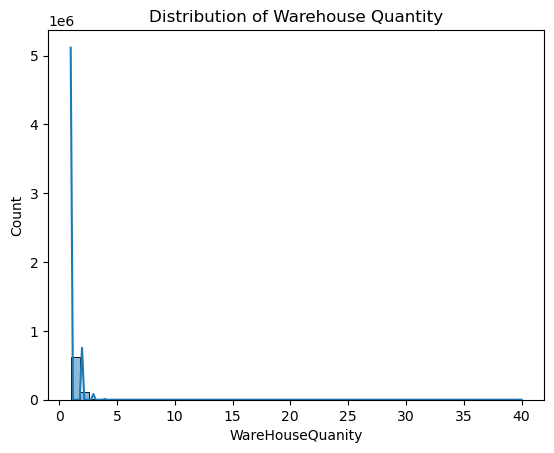

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['WareHouseQuanity'], bins=50, kde=True)
plt.title('Distribution of Warehouse Quantity')
plt.show()


In [149]:
df['WareHouseQuanity'].value_counts()

WareHouseQuanity
1.0     625479
2.0     105915
3.0      17690
4.0       4695
6.0       1038
5.0        423
8.0        107
7.0         56
10.0        51
12.0        36
9.0         31
20.0         9
15.0         7
11.0         7
14.0         7
13.0         4
16.0         3
18.0         2
17.0         2
22.0         1
21.0         1
40.0         1
23.0         1
28.0         1
Name: count, dtype: int64

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel('SKUForecastDataSet.xlsx')  # Replace with your file path


In [27]:
df.dropna(inplace=True)  # Drop rows with NULLs

In [28]:
df.isnull().sum()  # Check for any remaining NULLs

ProductFamily       0
order_id            0
OrderDate           0
Channel             0
OrderSource         0
SKU                 0
SKU_Description     0
ShipToState         0
WareHouseQuanity    0
SKU_category        0
OrderMonth          0
OrderDay            0
OrderYear           0
DayOfWeek           0
dtype: int64

c:\Users\Nilam Wadhavane\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Random Forest Performance:
MAE: 0.33
RMSE: 0.59
R² Score: -0.09


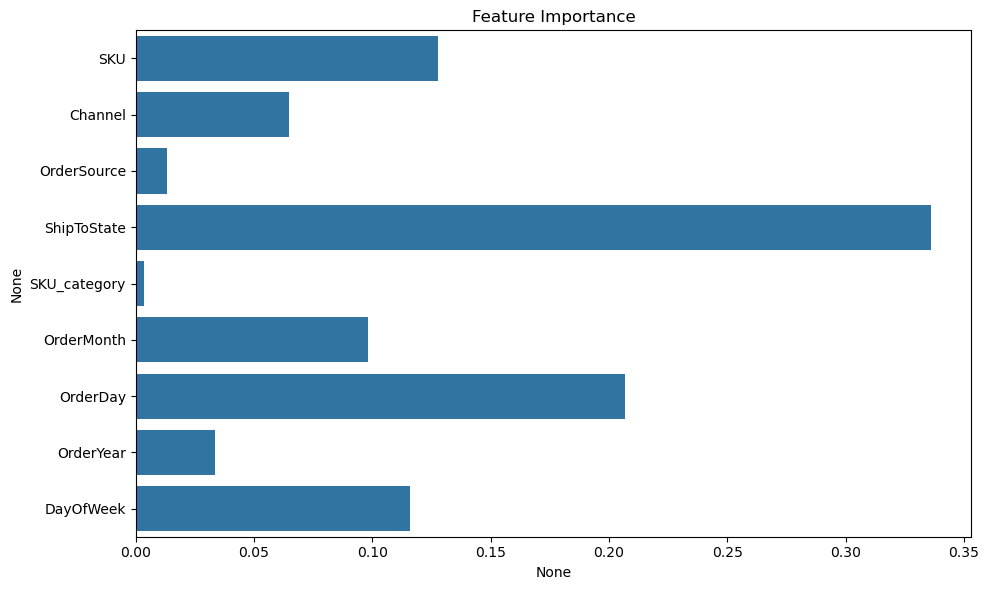

In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create date features
df['OrderMonth'] = df['OrderDate'].dt.month
df['OrderDay'] = df['OrderDate'].dt.day
df['OrderYear'] = df['OrderDate'].dt.year
df['DayOfWeek'] = df['OrderDate'].dt.dayofweek

# Encode categorical columns
categorical_cols = ['SKU', 'Channel', 'OrderSource', 'ShipToState', 'SKU_category']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # Save encoders if needed later

# Define features and target
features = ['SKU', 'Channel', 'OrderSource', 'ShipToState', 'SKU_category',
            'OrderMonth', 'OrderDay', 'OrderYear', 'DayOfWeek']
target = 'WareHouseQuanity'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Random Forest Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot feature importance
# importances = pd.Series(rf.feature_importances_, index=features)
# plt.figure(figsize=(10, 6))
# sns.barplot(x=importances, y=importances.index)
# plt.title("Feature Importance")
# plt.tight_layout()
# plt.show()
